In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import sys, os
import getdist
from getdist import plots, MCSamples
from chainconsumer import Chain, ChainConfig, ChainConsumer, PlotConfig, Truth, make_sample
sys.path.append('/pscratch/sd/m/myamamot/y6-cosmicshear/y6_cosmicshear/code')
from bias_functions import chain, calculate_bias_2d, calculate_bias_1d
import proplot as pplt
import pandas as pd
%matplotlib inline

In [2]:
# basic function for making a 2D contour plot
def plot_chain_pair(c1,c2,contaminated_chain_name, marker=(-9999,-9999)):
    samp1 = np.array([c1.samples['cosmological_parameters--omega_m'], c1.samples['cosmological_parameters--s8']])
    samp2 = np.array([c2.samples['cosmological_parameters--omega_m'], c2.samples['cosmological_parameters--s8']])
    
    print('Making cornerplot...')
    names = [r'$\Omega_{\rm m}$','$S_8$']
    
    plt.close()
    
    g = plots.get_single_plotter(width_inch=6, ratio=0.8)
    g.settings.legend_fontsize = 16
    g.settings.fontsize = 18
    g.settings.axes_fontsize = 16
    g.settings.axes_labelsize = 18
    g.settings.axis_tick_max_labels = 16
    g.settings.linewidth = 1.5
    g.settings.legend_colored_text=True
    g.settings.axis_tick_step_groups = [[2.5, 3, 4, 6, 8],[1, 2, 5, 10]]
    
    samples1 = MCSamples(samples=samp1.T,names=['x1','x2'], labels=names, label=r'Contaminated', weights=c1.weight, settings={'boundary_correction_order':0, 'mult_bias_correction_order':1}) #, 'smooth_scale_2D':0.6, 'smooth_scale_1D':0.3})
    samples2 = MCSamples(samples=samp2.T,names=['x1','x2'], labels=names, label=r'Contaminated', weights=c2.weight, settings={'boundary_correction_order':0, 'mult_bias_correction_order':1}) #, 'smooth_scale_2D':0.6, 'smooth_scale_1D':0.3})
    
    g.plot_2d([samples1, samples2],['x1','x2'], diag1d_kwargs={'normalized':True}, alphas=[0.6,1,1.,1], ls=[':','-','-','--'],lws=[1.5,1.5,1.5,1.5],filled=[True,False,False,False], colors=[colour,'k','steelblue','k' ], labels=['DES', 'KiDS'], lims=[0.18,0.55,0.71,0.86]) 
    
    plt.scatter([0.338],[0.77], color='k', marker='*')
    
    if marker[0]!=-9999.:
        plt.scatter([marker[1]],[marker[0]], color=colour, marker='D')
    
    g.add_legend([r'Baseline', r'Contaminated'], legend_loc='upper right')
    # plt.savefig('/Users/hattifattener/work/y6-cosmicshear/plots/scale_cuts_validation_%s.png'%contaminated_chain_name)
    plt.close()
    

def plot_chains(c, chains, labels, ls, alpha, Color, oms8=False, recenter=False, truth=True, save=False, outdir=None):
    kde = 2.0 #this controls how smooth the contours are

    names = ['weight', '$\Omega_{{m}}$','$\sigma_{8}$','$S_{{8}}$']
    for ic, (label, chain) in enumerate(zip(labels, chains)):
    
        try:
            df = pd.DataFrame.from_records(chain)[['log_weight', 'cosmological_parameters--omega_m', 'cosmological_parameters--sigma_8', 'cosmological_parameters--s_8']]
            mask = (np.exp(df['log_weight']) == 0)
            df = df[~mask]
            df['log_weight'] = np.exp(df['log_weight'])
            df.columns = names
        except:
            df = pd.DataFrame.from_records(chain)[['weight', 'cosmological_parameters--omega_m', 'cosmological_parameters--sigma_8']]
            mask = (df['weight'] == 0)
            df = df[~mask]
            
            om = df['cosmological_parameters--omega_m']
            sigma8 = df['cosmological_parameters--sigma_8']
            S8 = sigma8*np.sqrt(om/0.3)
            df_s8 = pd.DataFrame(S8, columns=['cosmological_parameters--s_8'])
            df = df.join(df_s8, how='right')
            df.columns = names
            
        if recenter:
            df['$S_{{8}}$'] -= np.average(df['$S_{{8}}$'], weights=df['weight'])
            df['$\Omega_{{m}}$'] -= np.average(df['$\Omega_{{m}}$'], weights=df['weight'])
            df['$\sigma_{8}$'] -= np.average(df['$\sigma_{8}$'], weights=df['weight'])
        if oms8:
            df = df[['$S_{{8}}$', '$\Omega_{{m}}$', 'weight']]
            c_ = Chain(samples=df, weight_column='weight', name=label, kde=kde, shade=True, shade_alpha=alpha[ic], linewidth=2.0, linestyle=ls[ic])
        else:
            c_ = Chain(samples=df, weight_column='weight', name=label, kde=kde, shade=True, shade_alpha=alpha[ic], linewidth=2.0, linestyle=ls[ic])
        # config = ChainConfig(kde=kde, shade_gradient = 0.1, shade_alpha=alpha[ic], linestyles=ls[ic],)
        # c.set_override(config)
        c.add_chain(c_)

    # config = ChainConfig(sigma2d=False, kde=kde, plot_hists=True,
    #                      legend_kwargs={"loc": "upper right", "fontsize": 24, "handlelength": 1.25}, label_font_size=20, tick_font_size=7,  
    #                      shade_gradient = 0.1,legend_color_text=True, diagonal_tick_labels=False, linestyles=[':', '-', '-', '--', ':'], 
    #                      colors=Color[:6], linewidths=[2.0,2.0,2.0,2.0,2.0],shade=['True','True','True','True','False'])
    # config = ChainConfig(kde=kde, shade_gradient = 0.1)
    # c.set_override(config)
    if truth:
        if oms8:
            c.add_truth(Truth(location={'$\Omega_{{m}}$': 0.31, 
                                        '$S_{{8}}$': 0.77}, color="#500724"))
        else:
            c.add_truth(Truth(location={'$\Omega_{{m}}$': 0.31, 
                                        '$\sigma_{8}$': 0.76, 
                                        '$S_{{8}}$': 0.77}, color="#500724"))
    c.set_plot_config(
    PlotConfig(
        plot_hists=True,legend_kwargs={"loc": "upper right", "fontsize": 20, "handlelength": 1.25}, label_font_size=20, tick_font_size=10))

    fig = c.plotter.plot()
    # fig2 = c.plotter.plot_summary(errorbar=True)
    print(c.analysis.get_latex_table())
    if save:
        plt.savefig(outdir, bbox_inches='tight')
    plt.show()
    
def plot_chains_noncosmo(c, chains, params, labels, ls, alpha, Color, oms8=False, recenter=False, truth=True, save=False, outdir=None):
    kde = 2.0 #this controls how smooth the contours are

    names_dict = {'log_weight': 'weight', 'weight': 'weight', 'cosmological_parameters--omega_m': '$\Omega_{{m}}$',
                  'cosmological_parameters--sigma_8': '$\sigma_{8}$', 'cosmological_parameters--s_8': '$S_{{8}}$', 
                  'source_photoz_u--u_0': '$u_0$', 'source_photoz_u--u_1': '$u_1$', 
                  'source_photoz_u--u_2': '$u_2$', 'source_photoz_u--u_3': '$u_3$', 
                  'source_photoz_u--u_4': '$u_4$', 'source_5_unsmooth_coarse_photoz_u--u_0': '$u_0$', 'source_5_unsmooth_coarse_photoz_u--u_1': '$u_1$', 
                  'source_5_unsmooth_coarse_photoz_u--u_2': '$u_2$', 'source_5_unsmooth_coarse_photoz_u--u_3': '$u_3$', 
                  'source_5_unsmooth_coarse_photoz_u--u_4': '$u_4$'}
    names = []
    for ic, (label, chain) in enumerate(zip(labels, chains)):
    
        try:
            df = pd.DataFrame.from_records(chain)[params]
            mask = (np.exp(df['log_weight']) == 0)
            df = df[~mask]
            df['log_weight'] = np.exp(df['log_weight'])
            for param in params:
                names.append(names_dict[param])
            df.columns = names
        except:
            df = pd.DataFrame.from_records(chain)[params]
            mask = (df['weight'] == 0)
            df = df[~mask]
            if 'cosmological_parameters--omega_m' in params:
                om = df['cosmological_parameters--omega_m']
                sigma8 = df['cosmological_parameters--sigma_8']
                S8 = sigma8*np.sqrt(om/0.3)
                df_s8 = pd.DataFrame(S8, columns=['cosmological_parameters--s_8'])
                df = df.join(df_s8, how='right')
            for param in params:
                names.append(names_dict[param])
            df.columns = names
            
        if recenter:
            for name in names:
                df[name] -= np.average(df[name], weights=df['weight'])

        c_ = Chain(samples=df, weight_column='weight', name=label, kde=kde, shade=True, shade_alpha=alpha[ic], linewidth=2.0, linestyle=ls[ic])
        # config = ChainConfig(kde=kde, shade_gradient = 0.1, shade_alpha=alpha[ic], linestyles=ls[ic],)
        # c.set_override(config)
        c.add_chain(c_)

    # config = ChainConfig(sigma2d=False, kde=kde, plot_hists=True,
    #                      legend_kwargs={"loc": "upper right", "fontsize": 24, "handlelength": 1.25}, label_font_size=20, tick_font_size=7,  
    #                      shade_gradient = 0.1,legend_color_text=True, diagonal_tick_labels=False, linestyles=[':', '-', '-', '--', ':'], 
    #                      colors=Color[:6], linewidths=[2.0,2.0,2.0,2.0,2.0],shade=['True','True','True','True','False'])
    # config = ChainConfig(kde=kde, shade_gradient = 0.1)
    # c.set_override(config)
    if truth:
        if '$\Omega_{{m}}$' in names:
            if oms8:
                c.add_truth(Truth(location={'$\Omega_{{m}}$': 0.31, 
                                            '$S_{{8}}$': 0.77}, color="#500724"))
            else:
                c.add_truth(Truth(location={'$\Omega_{{m}}$': 0.31, 
                                            '$\sigma_{8}$': 0.76, 
                                            '$S_{{8}}$': 0.77}, color="#500724"))
    c.set_plot_config(
    PlotConfig(
        plot_hists=True,legend_kwargs={"loc": "upper right", "fontsize": 20, "handlelength": 1.25}, label_font_size=20, tick_font_size=10))

    fig = c.plotter.plot()
    # fig2 = c.plotter.plot_summary(errorbar=True)
    print(c.analysis.get_latex_table())
    if save:
        plt.savefig(outdir, bbox_inches='tight')
    plt.show()

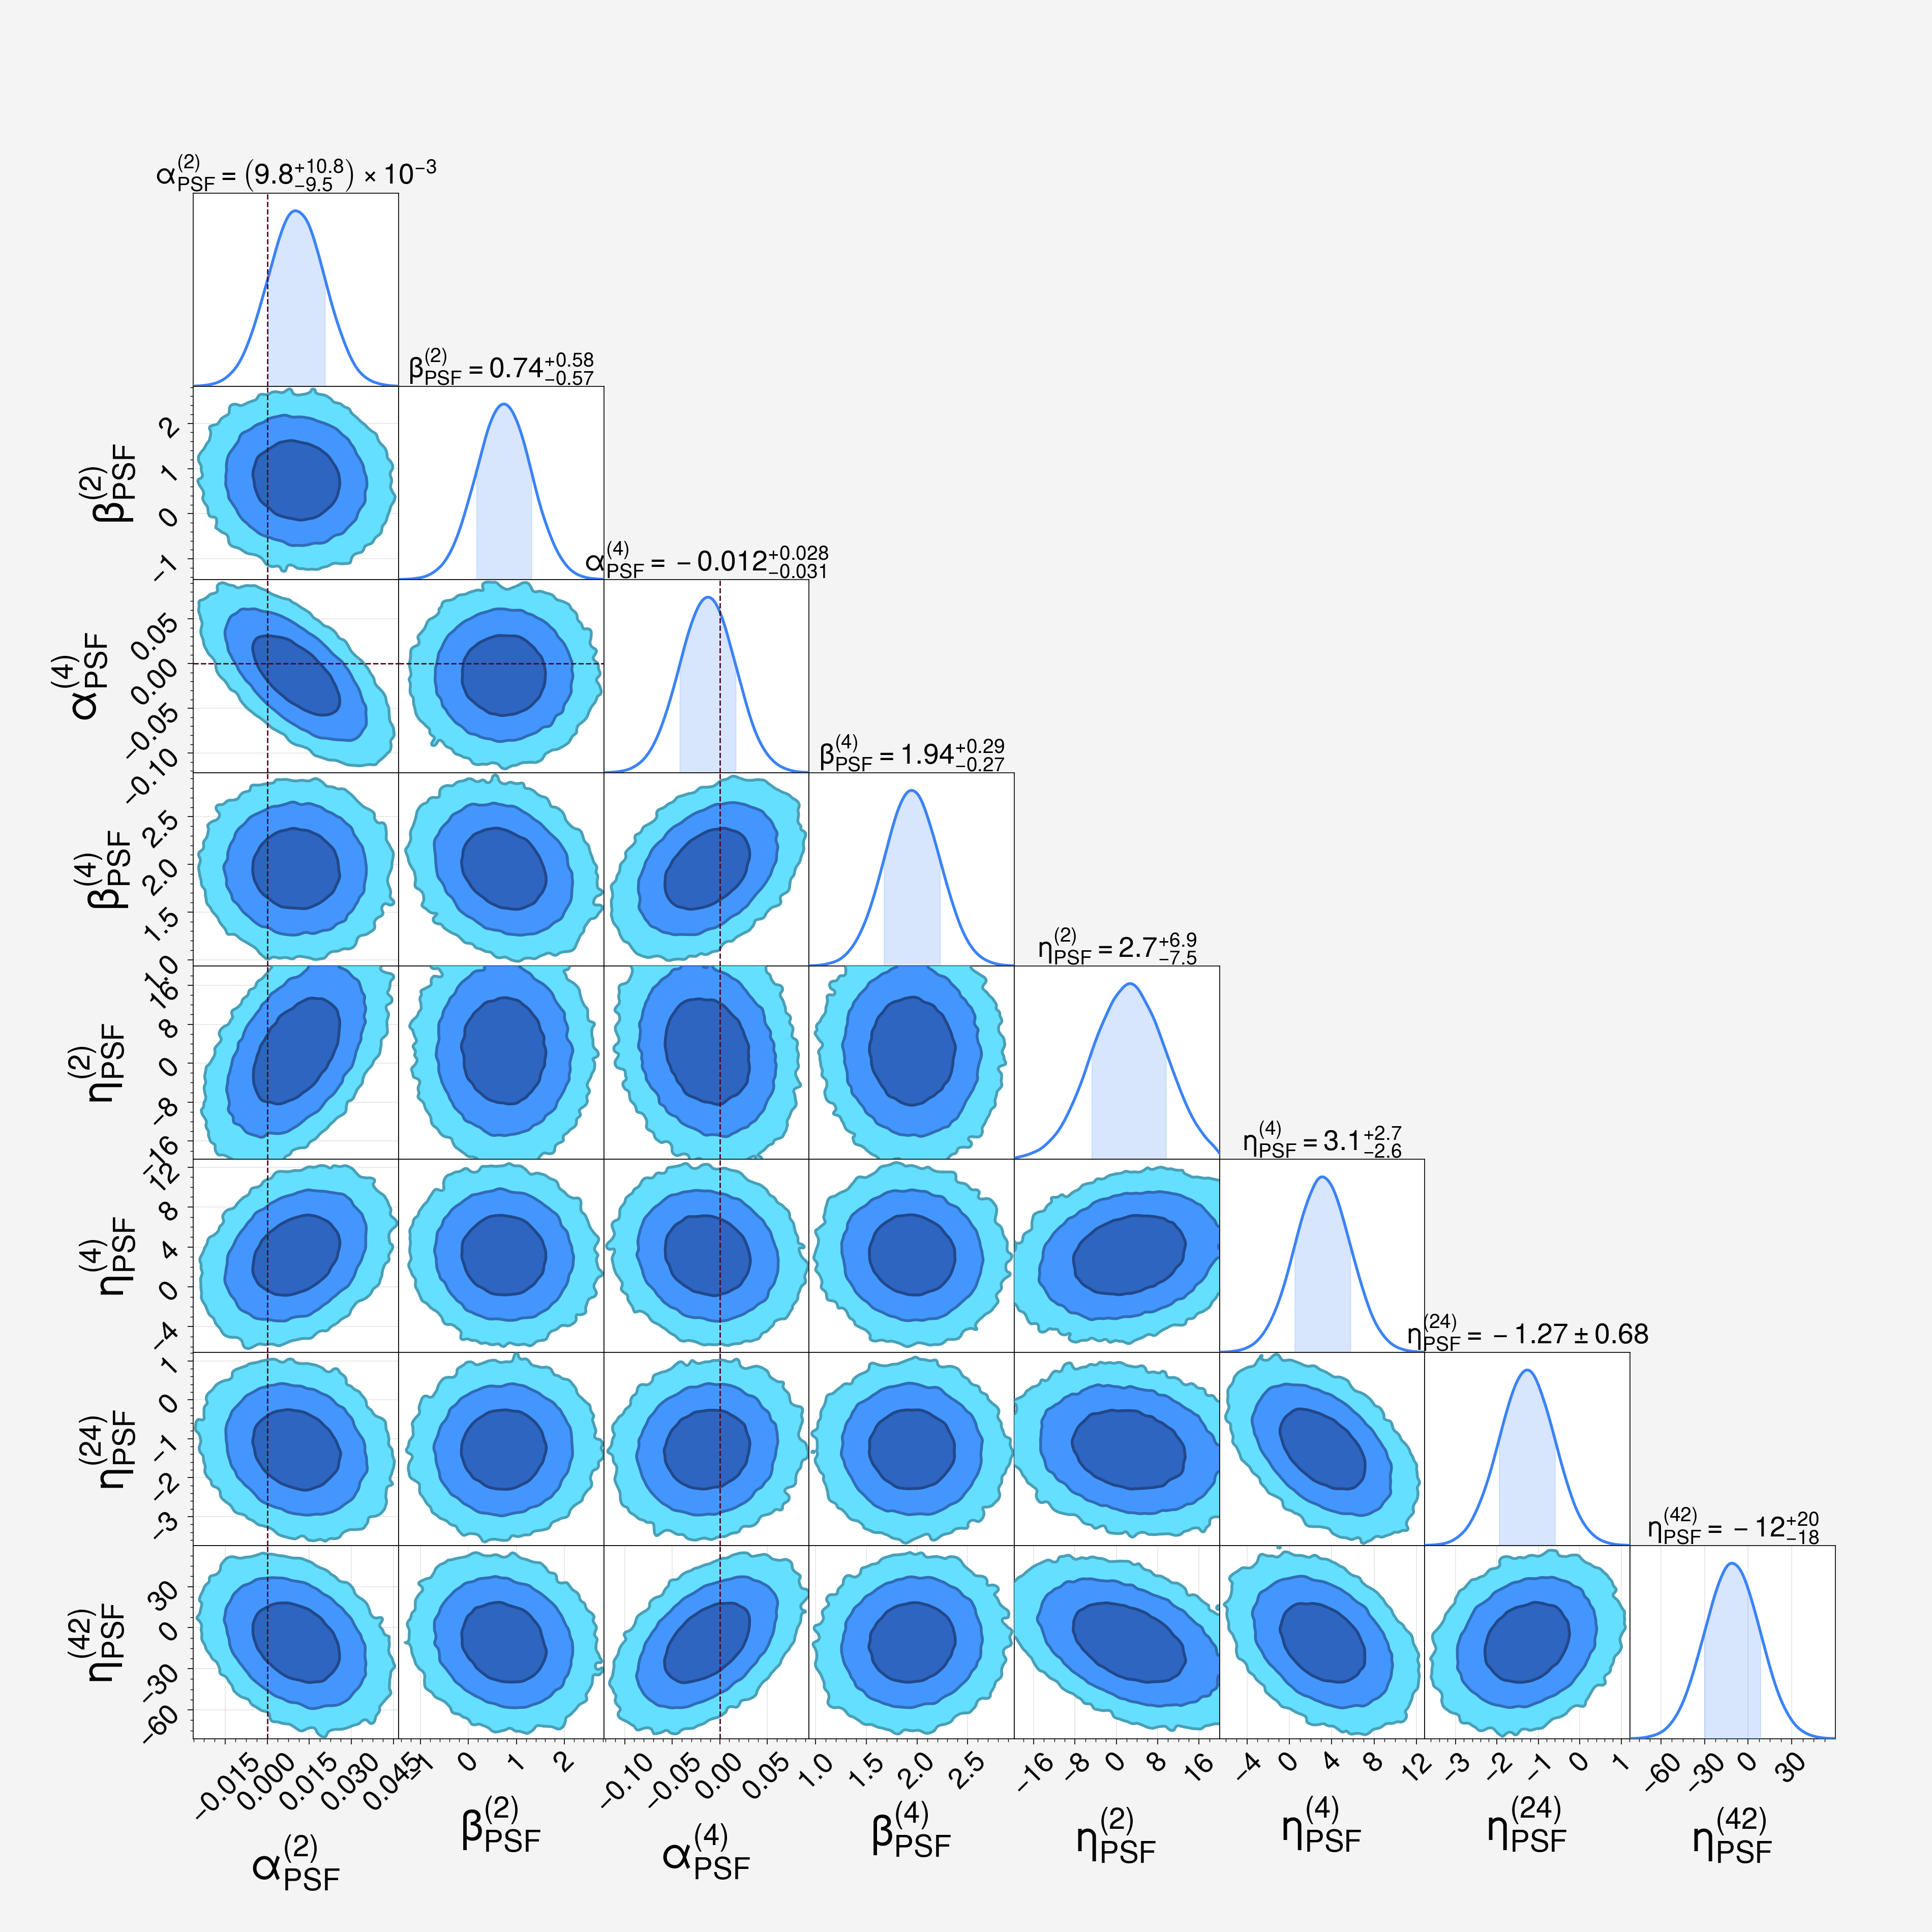

In [5]:
c = ChainConsumer()
matplotlib.rcParams.update({'font.size': 32, 'legend.fontsize':'x-small', 'lines.markersize':8})
label = ''
params = [r'$\alpha^{(2)}_\mathrm{PSF}$',r'$\beta^{(2)}_\mathrm{PSF}$',r'$\alpha^{(4)}_\mathrm{PSF}$',r'$\beta^{(4)}_\mathrm{PSF}$','$\eta^{(2)}_\mathrm{PSF}$', '$\eta^{(4)}_\mathrm{PSF}$', '$\eta^{(24)}_\mathrm{PSF}$', '$\eta^{(42)}_\mathrm{PSF}$']
chain = np.genfromtxt('/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/rho_tau_stats/fiducial_8params_32bins_101924/flatchain_simgp.txt', names = params, deletechars='', case_sensitive=True)


df = pd.DataFrame.from_records(chain)
c_ = Chain(samples=df, name=label, kde=0., shade=True, alpha=0.7, linewidth=2.0, cmap='rocket')
c.add_chain(c_)
c.set_override(ChainConfig(sigmas=[0, 1, 2, 3]))
c.add_truth(Truth(location={'$\\alpha^{(2)}_\\mathrm{PSF}$': 0.0, '$\\alpha^{(4)}_\\mathrm{PSF}$': 0.0}, color="#500724"))
                            # '$\\beta^{(2)}_\\mathrm{PSF}$': 1.0, '$\\beta^{(4)}_\\mathrm{PSF}$': 1.0, 
                            # '$\\eta^{(2)}_\\mathrm{PSF}$': 1.0, '$\\eta^{(4)}_\\mathrm{PSF}$': 1.0, 
                            # '$\\eta^{(24)}_\\mathrm{PSF}$': 1.0, '$\\eta^{(42)}_\\mathrm{PSF}$': 1.0}, color="#500724"))

# c.configure(global_point=True,statistics='mean',label_font_size=20,)
c.set_plot_config(
PlotConfig(
    plot_hists=True,legend_kwargs={"loc": "upper right", "fontsize": 'large', "handlelength": 1.75}, summary_font_size=20, label_font_size=30, tick_font_size=20, ))

# formatter = matplotlib.ticker.ScalarFormatter(useOffset=False)
# formatter.set_scientific(False)
fig = c.plotter.plot()


# fig = c.plotter.plot(figsize="PAGE")
# stat=c.analysis.get_summary()

# fig.subplots_adjust(wspace=-0.02,hspace=-0.02)
plt.savefig('/global/homes/m/myamamot/DES/des-y6-analysis/vf_figures/v6_UNBLINDED/mcmc_posteriors_simgp_2.5_250_32bins.pdf', bbox_inches='tight', dpi=100)

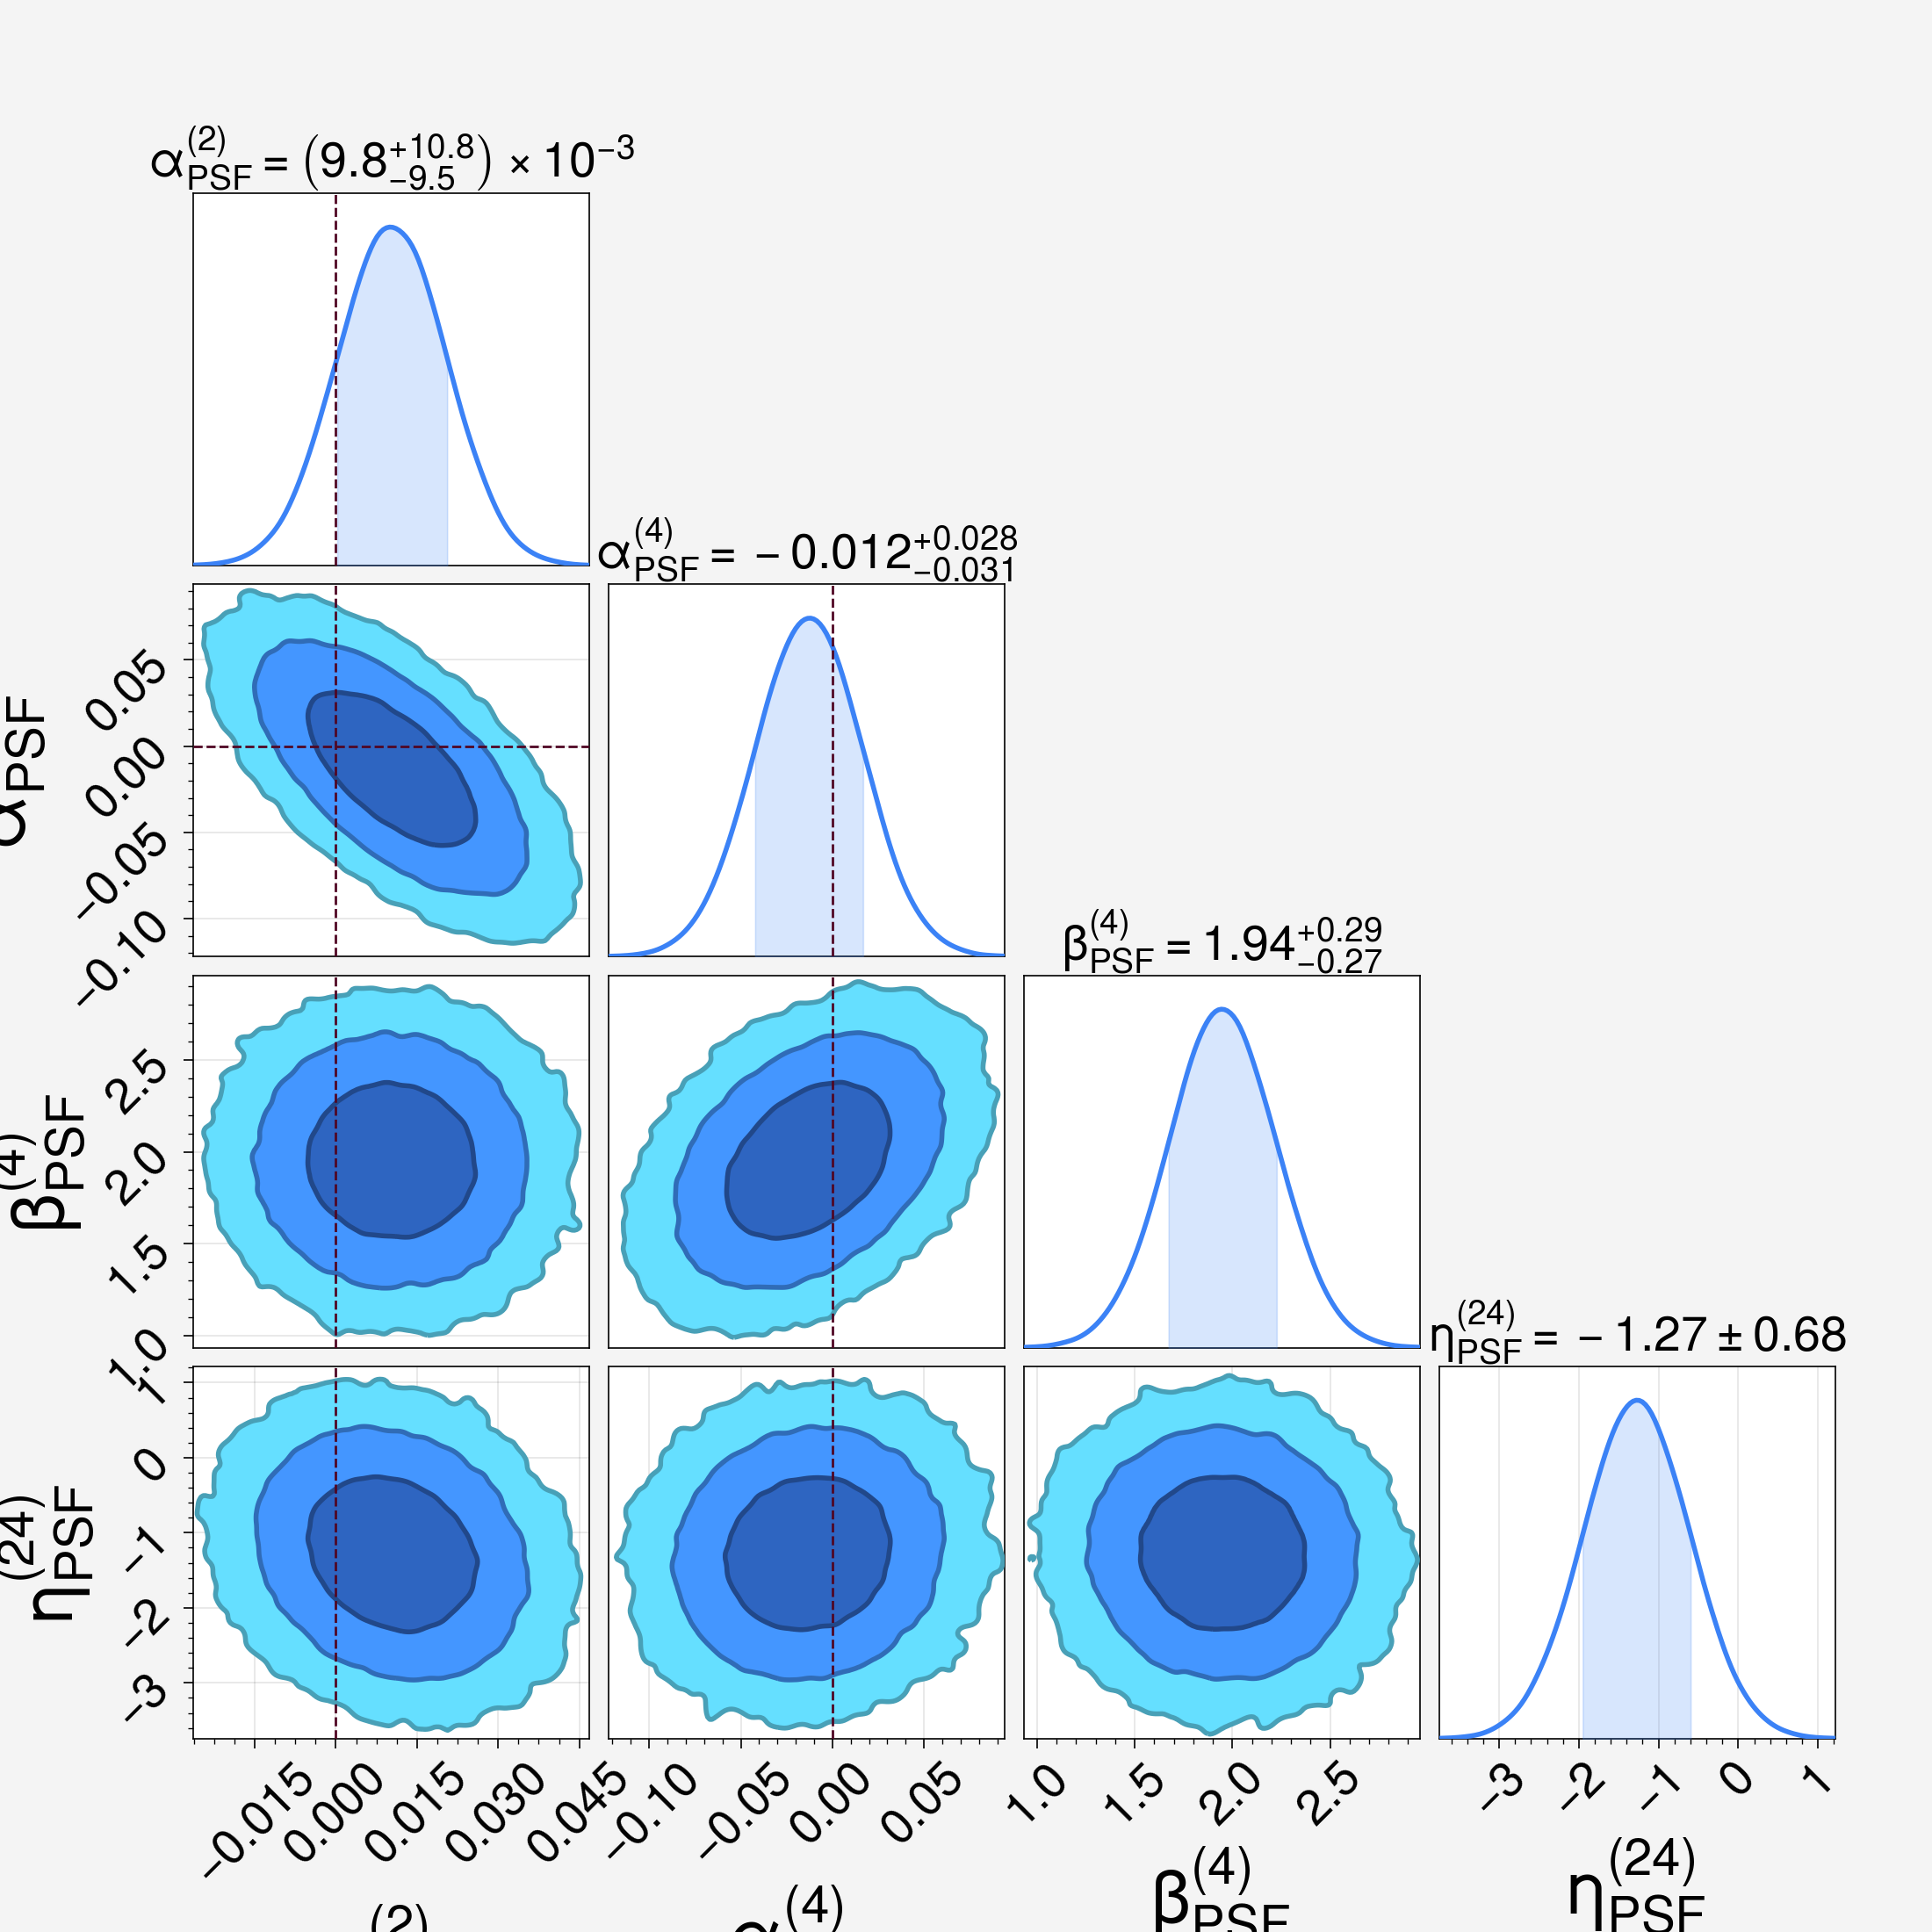

In [6]:
c = ChainConsumer()
matplotlib.rcParams.update({'font.size': 25, 'legend.fontsize':'x-small', 'lines.markersize':8})
label = ''
params = [r'$\alpha^{(2)}_\mathrm{PSF}$',r'$\beta^{(2)}_\mathrm{PSF}$',r'$\alpha^{(4)}_\mathrm{PSF}$',r'$\beta^{(4)}_\mathrm{PSF}$','$\eta^{(2)}_\mathrm{PSF}$', '$\eta^{(4)}_\mathrm{PSF}$', '$\eta^{(24)}_\mathrm{PSF}$', '$\eta^{(42)}_\mathrm{PSF}$']
# params = [r'$\alpha^{(2)}_\mathrm{PSF}$',r'$\alpha^{(4)}_\mathrm{PSF}$',r'$\beta^{(4)}_\mathrm{PSF}$','$\eta^{(24)}_\mathrm{PSF}$']
chain = np.genfromtxt('/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/rho_tau_stats/fiducial_8params_32bins_101924/flatchain_simgp.txt', names = params, deletechars='', case_sensitive=True)


df = pd.DataFrame.from_records(chain)
c_ = Chain(samples=df[[r'$\alpha^{(2)}_\mathrm{PSF}$',r'$\alpha^{(4)}_\mathrm{PSF}$',r'$\beta^{(4)}_\mathrm{PSF}$','$\eta^{(24)}_\mathrm{PSF}$']], name=label, kde=0., shade=True, alpha=0.7, linewidth=2.0, cmap='rocket')
c.add_chain(c_)
c.set_override(ChainConfig(sigmas=[0, 1, 2, 3]))
c.add_truth(Truth(location={'$\\alpha^{(2)}_\\mathrm{PSF}$': 0.0, '$\\alpha^{(4)}_\\mathrm{PSF}$': 0.0}, color="#500724"))

# c.configure(global_point=True,statistics='mean',label_font_size=20,)
c.set_plot_config(
PlotConfig(
    plot_hists=True,legend_kwargs={"loc": "upper right", "fontsize": 'medium', "handlelength": 1.75}, summary_font_size=20, label_font_size=30, tick_font_size=20, ))

# formatter = matplotlib.ticker.ScalarFormatter(useOffset=False)
# formatter.set_scientific(False)
fig = c.plotter.plot()


# fig = c.plotter.plot(figsize="PAGE")
# stat=c.analysis.get_summary()

# fig.subplots_adjust(wspace=-0.02,hspace=-0.02)
plt.savefig('/global/homes/m/myamamot/DES/des-y6-analysis/vf_figures/v6_UNBLINDED/mcmc_posteriors_simgp_2.5_250_32bins_subset.pdf', bbox_inches='tight', dpi=100)

In [7]:
df

,$\alpha^{(2)}_\mathrm{PSF}$,$\alpha^{(4)}_\mathrm{PSF}$,$\beta^{(4)}_\mathrm{PSF}$,$\eta^{(24)}_\mathrm{PSF}$
0,0.011910,0.321462,-0.017737,1.315204
1,0.010754,0.777923,-0.023186,2.029648
2,0.003660,1.733737,0.031971,2.407776
3,0.003004,-0.176480,0.002154,2.458420
4,0.026655,0.031706,-0.020562,2.189629
...,...,...,...,...
191995,0.023887,0.640736,-0.041909,1.486661
191996,0.014617,0.889931,-0.009458,1.693283
191997,0.007894,1.672760,-0.028929,1.872099
191998,0.018532,0.400265,0.026613,2.381609


## Fixing pz error

In [3]:
path_chains = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/pz/'
path_save = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER'

filename_y3dz = os.path.join(path_chains,'y3dz/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_y6dz = os.path.join(path_chains,'y6dz/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_nodz = os.path.join(path_chains,'nodz/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_desy3fid = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/chain_1x2pt_lcdm_SR_maglim.txt'
filename_desy3opt = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/chain_1x2agg_NLA_ML.txt'

### getdist code

In [ ]:
chain_base = chain(filename=filename_base)
chain_pz = chain(filename=filename_pz)
chain_nopz = chain(filename=filename_nopz)

chain_base.add_s8()
chain_pz.add_s8()
chain_nopz.add_s8()

In [ ]:
chains_contaminations = [chain_pz, chain_nopz]
chains_labels = ['Y6 pz err', 'No pz err']
figure_labels = ['Y6pzerr', 'Nopzerr']
for i,c_ in enumerate(chains_contaminations):
    calculate_bias_2d(chain1=chain_base,
                      chain2=c_,
                      show=True,
                      weights_list=None,
                      input_values=[0.77,0.31],
                      xy=(0.34,0.61),
                      labels=['Baseline',chains_labels[i]])


    plt.legend(loc='upper right',frameon=False,fontsize=12)
    plt.tight_layout()
    # plt.savefig(os.path.join(path_save,'bias2D_baseline_cont-%s.pdf'%figure_labels[i]), bbox_inches='tight')
    plt.show()

In [ ]:
calculate_bias_2d(chain1=chain_pz,
                  chain2=chain_nopz,
                  show=True,
                  weights_list=None,
                  input_values=[0.77,0.31],
                  xy=(0.34,0.61),
                  labels=[chains_labels[0],chains_labels[1]])


plt.legend(loc='upper right',frameon=False,fontsize=12)
plt.tight_layout()
# plt.savefig(os.path.join(path_save,'bias2D_baseline_cont-%s.pdf'%figure_labels[i]), bbox_inches='tight')
plt.show()

### chainconsumer code

\begin{table}
    \centering
    \caption{}
    \label{tab:model_params}
    \begin{tabular}{cccc}
        \hline
		Model & $\Omega_{{m}}$ & $\sigma_{8}$ & $S_{{8}}$ \\ 
		\hline
		Y3 dz & $0.315^{+0.053}_{-0.046}$ & $0.737\pm 0.064$ & $0.764\pm 0.017$ \\ 
		No dz & $0.318^{+0.048}_{-0.045}$ & $0.737^{+0.063}_{-0.060}$ & $0.764\pm 0.016$ \\ 
		Y6 dz & $0.317^{+0.052}_{-0.048}$ & $0.734^{+0.069}_{-0.063}$ & $0.764\pm 0.019$ \\ 
		DES Y3 1x2pt & $0.278^{+0.065}_{-0.055}$ & $0.773^{+0.101}_{-0.094}$ & $0.759\pm 0.027$ \\ 
		DES Y3 1x2pt Optimized & $0.282^{+0.055}_{-0.054}$ & $0.794^{+0.091}_{-0.081}$ & $0.778\pm 0.019$ \\ 
		\hline
    \end{tabular}
\end{table}


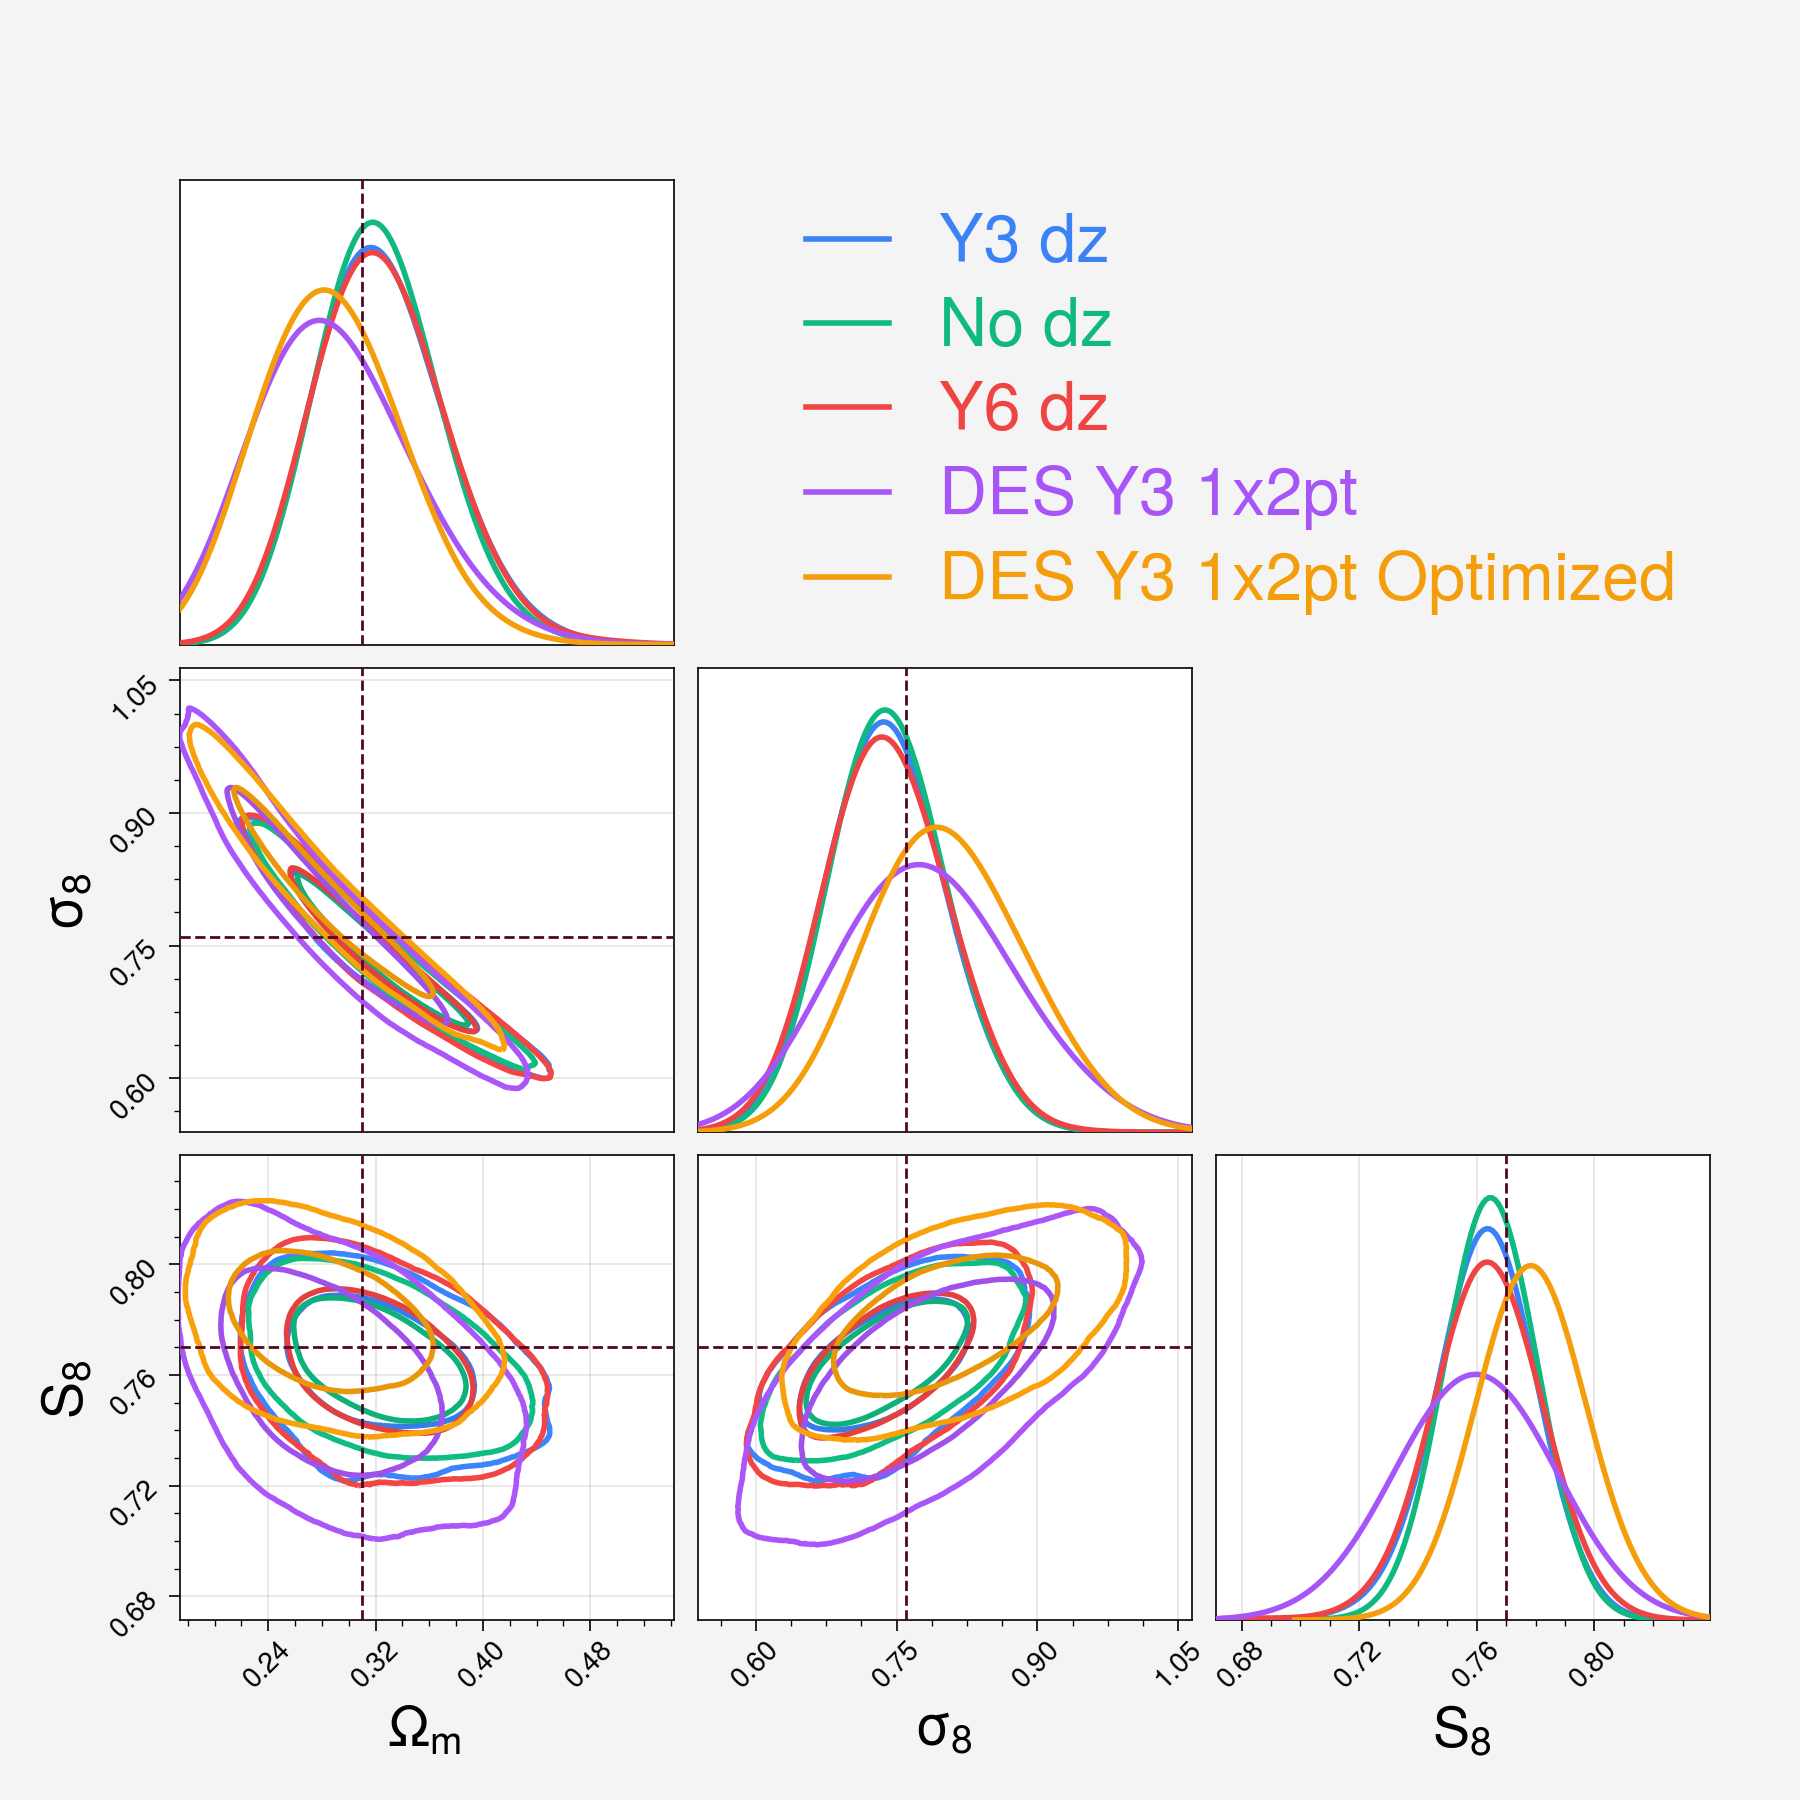

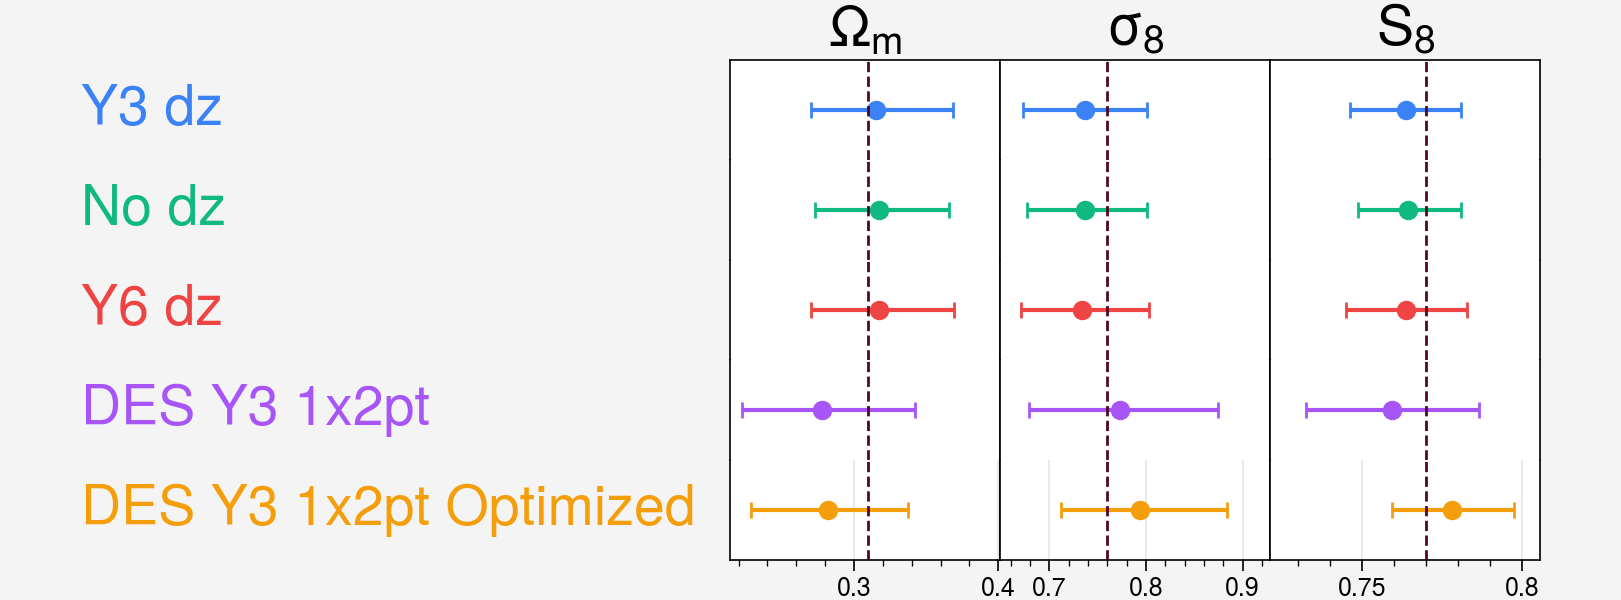

In [13]:
c = ChainConsumer()
labels = np.array(['Y3 dz', 'No dz', 'Y6 dz', 'DES Y3 1x2pt', 'DES Y3 1x2pt Optimized'])
chains = [np.genfromtxt(filename_y3dz, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_nodz, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_y6dz, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_desy3fid, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_desy3opt, names = True, deletechars='', case_sensitive='lower')] 
plot_chains(c, chains, labels, recenter=True)

In [10]:
path_chains_pz = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/pz/'
path_chains_nocuts = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/nocuts/'
path_chains_m = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/shearbias/'
path_chains_nosys = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/nosys/'
path_save = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/'


filename_y6dz = os.path.join(path_chains_pz,'y6dz/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_y6dz_nocuts = os.path.join(path_chains_nocuts,'y6dz/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_nocuts.ini.txt')
filename_y6dz_noIA = os.path.join(path_chains_pz,'fixed_IA/y6dz/chain_d1_l-hm20f-nlay6sim-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_nodz = os.path.join(path_chains_pz,'nodz/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_nodz_noIA = os.path.join(path_chains_nocuts,'y6dz_noIA/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_nocuts.ini.txt')
filename_y6dz_nom = os.path.join(path_chains_m,'chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_y6 = os.path.join(path_chains_nosys,'chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_nocuts.ini.txt')

\begin{table}
    \centering
    \caption{}
    \label{tab:model_params}
    \begin{tabular}{ccc}
        \hline
		Model & $S_{{8}}$ & $\Omega_{{m}}$ \\ 
		\hline
		Y6 dz & $0.000\pm 0.019$ & $-0.007^{+0.052}_{-0.048}$ \\ 
		Y6 dz, No cuts & $0.000\pm 0.013$ & $-0.005^{+0.045}_{-0.042}$ \\ 
		No dz & $0.000\pm 0.016$ & $-0.005^{+0.048}_{-0.045}$ \\ 
		Y6 dz, fixed IA & $0.000^{+0.018}_{-0.017}$ & $-0.006^{+0.050}_{-0.047}$ \\ 
		Y6 dz, No m & $0.000\pm 0.018$ & $-0.007^{+0.052}_{-0.046}$ \\ 
		No sys & $\left( 0.6^{+8.0}_{-8.5} \right) \times 10^{-3}$ & $-0.003^{+0.036}_{-0.034}$ \\ 
		\hline
    \end{tabular}
\end{table}


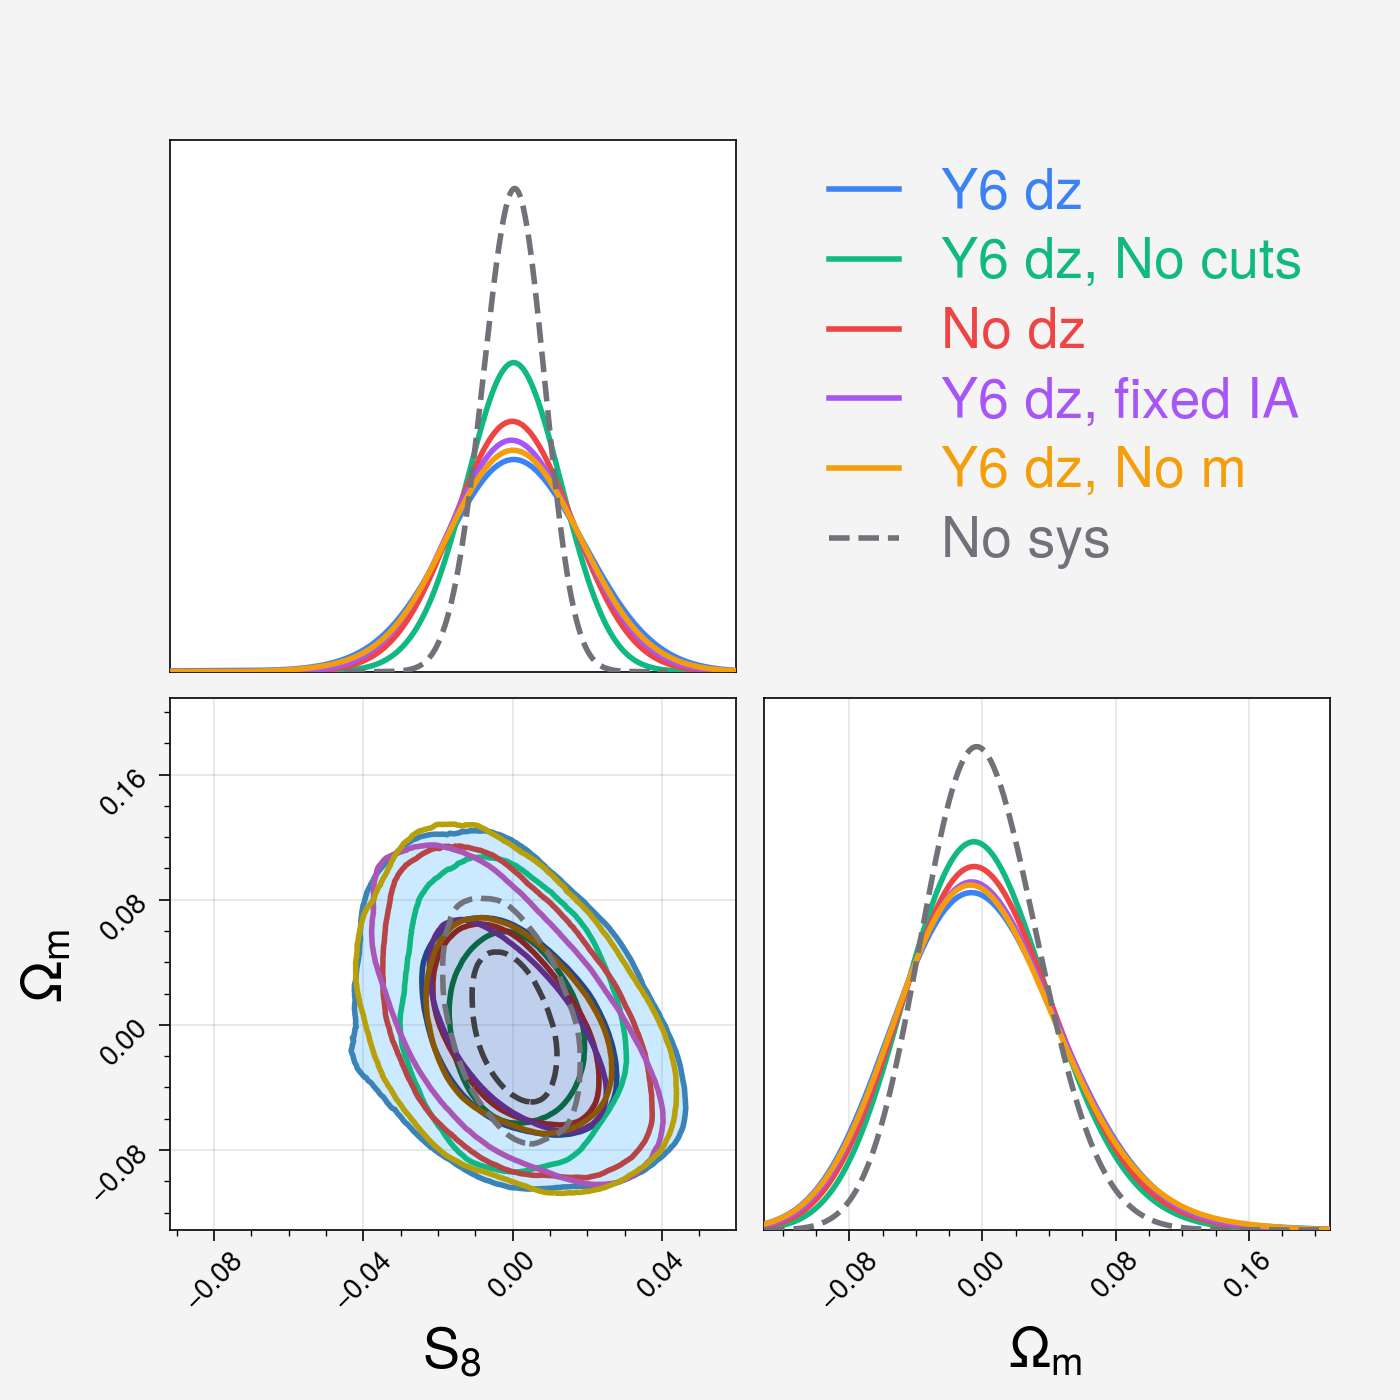

In [13]:
c = ChainConsumer()
labels = np.array(['Y6 dz', 'Y6 dz, No cuts', 'No dz', 'Y6 dz, fixed IA', 'Y6 dz, No m', 'No sys'])
lstyles = ['-', '-', '-', '-', '-', '--']
Color = ['#e13102','#016e51','#ffa500','#12239e','k'] 
alphas = [0.3,0.,0.,0.,0.,0.] 
chains = [np.genfromtxt(filename_y6dz, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_y6dz_nocuts, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_nodz, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_y6dz_noIA, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_y6dz_nom, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_y6, names = True, deletechars='', case_sensitive='lower')] 
plot_chains(c, chains, labels, lstyles, alphas, Color, oms8=True, recenter=True, save=True, outdir=path_save+'y6headline_individual_sys_oms8.pdf')

## Mode sampling 

In [8]:
path_chains_pz = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/pz/'
path_save = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/'


filename_y6dz = os.path.join(path_chains_pz,'y6dz/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_nodz = os.path.join(path_chains_pz,'nodz/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_mode = os.path.join(path_chains_pz,'mode/chain_d1_l-hm20f-nla-bfix_mode_test.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_mode_old = os.path.join(path_chains_pz,'mode/chain_d1_l-hm20f-nla-bfix_nzmode_test.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_mode_y6dz = os.path.join(path_chains_pz,'mode/y6dz/chain_d1_l-hm20f-nla-bfix_mode_test.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')

\begin{table}
    \centering
    \caption{}
    \label{tab:model_params}
    \begin{tabular}{cccc}
        \hline
		Model & $\Omega_{{m}}$ & $\sigma_{8}$ & $S_{{8}}$ \\ 
		\hline
		Y6 dz & $0.317^{+0.052}_{-0.048}$ & $0.734^{+0.069}_{-0.063}$ & $0.764\pm 0.019$ \\ 
		No dz & $0.318^{+0.048}_{-0.045}$ & $0.737^{+0.063}_{-0.060}$ & $0.764\pm 0.016$ \\ 
		Y6dz + Mode sampling (5) & $0.317^{+0.048}_{-0.044}$ & $0.738^{+0.062}_{-0.061}$ & $0.765\pm 0.016$ \\ 
		\hline
    \end{tabular}
\end{table}


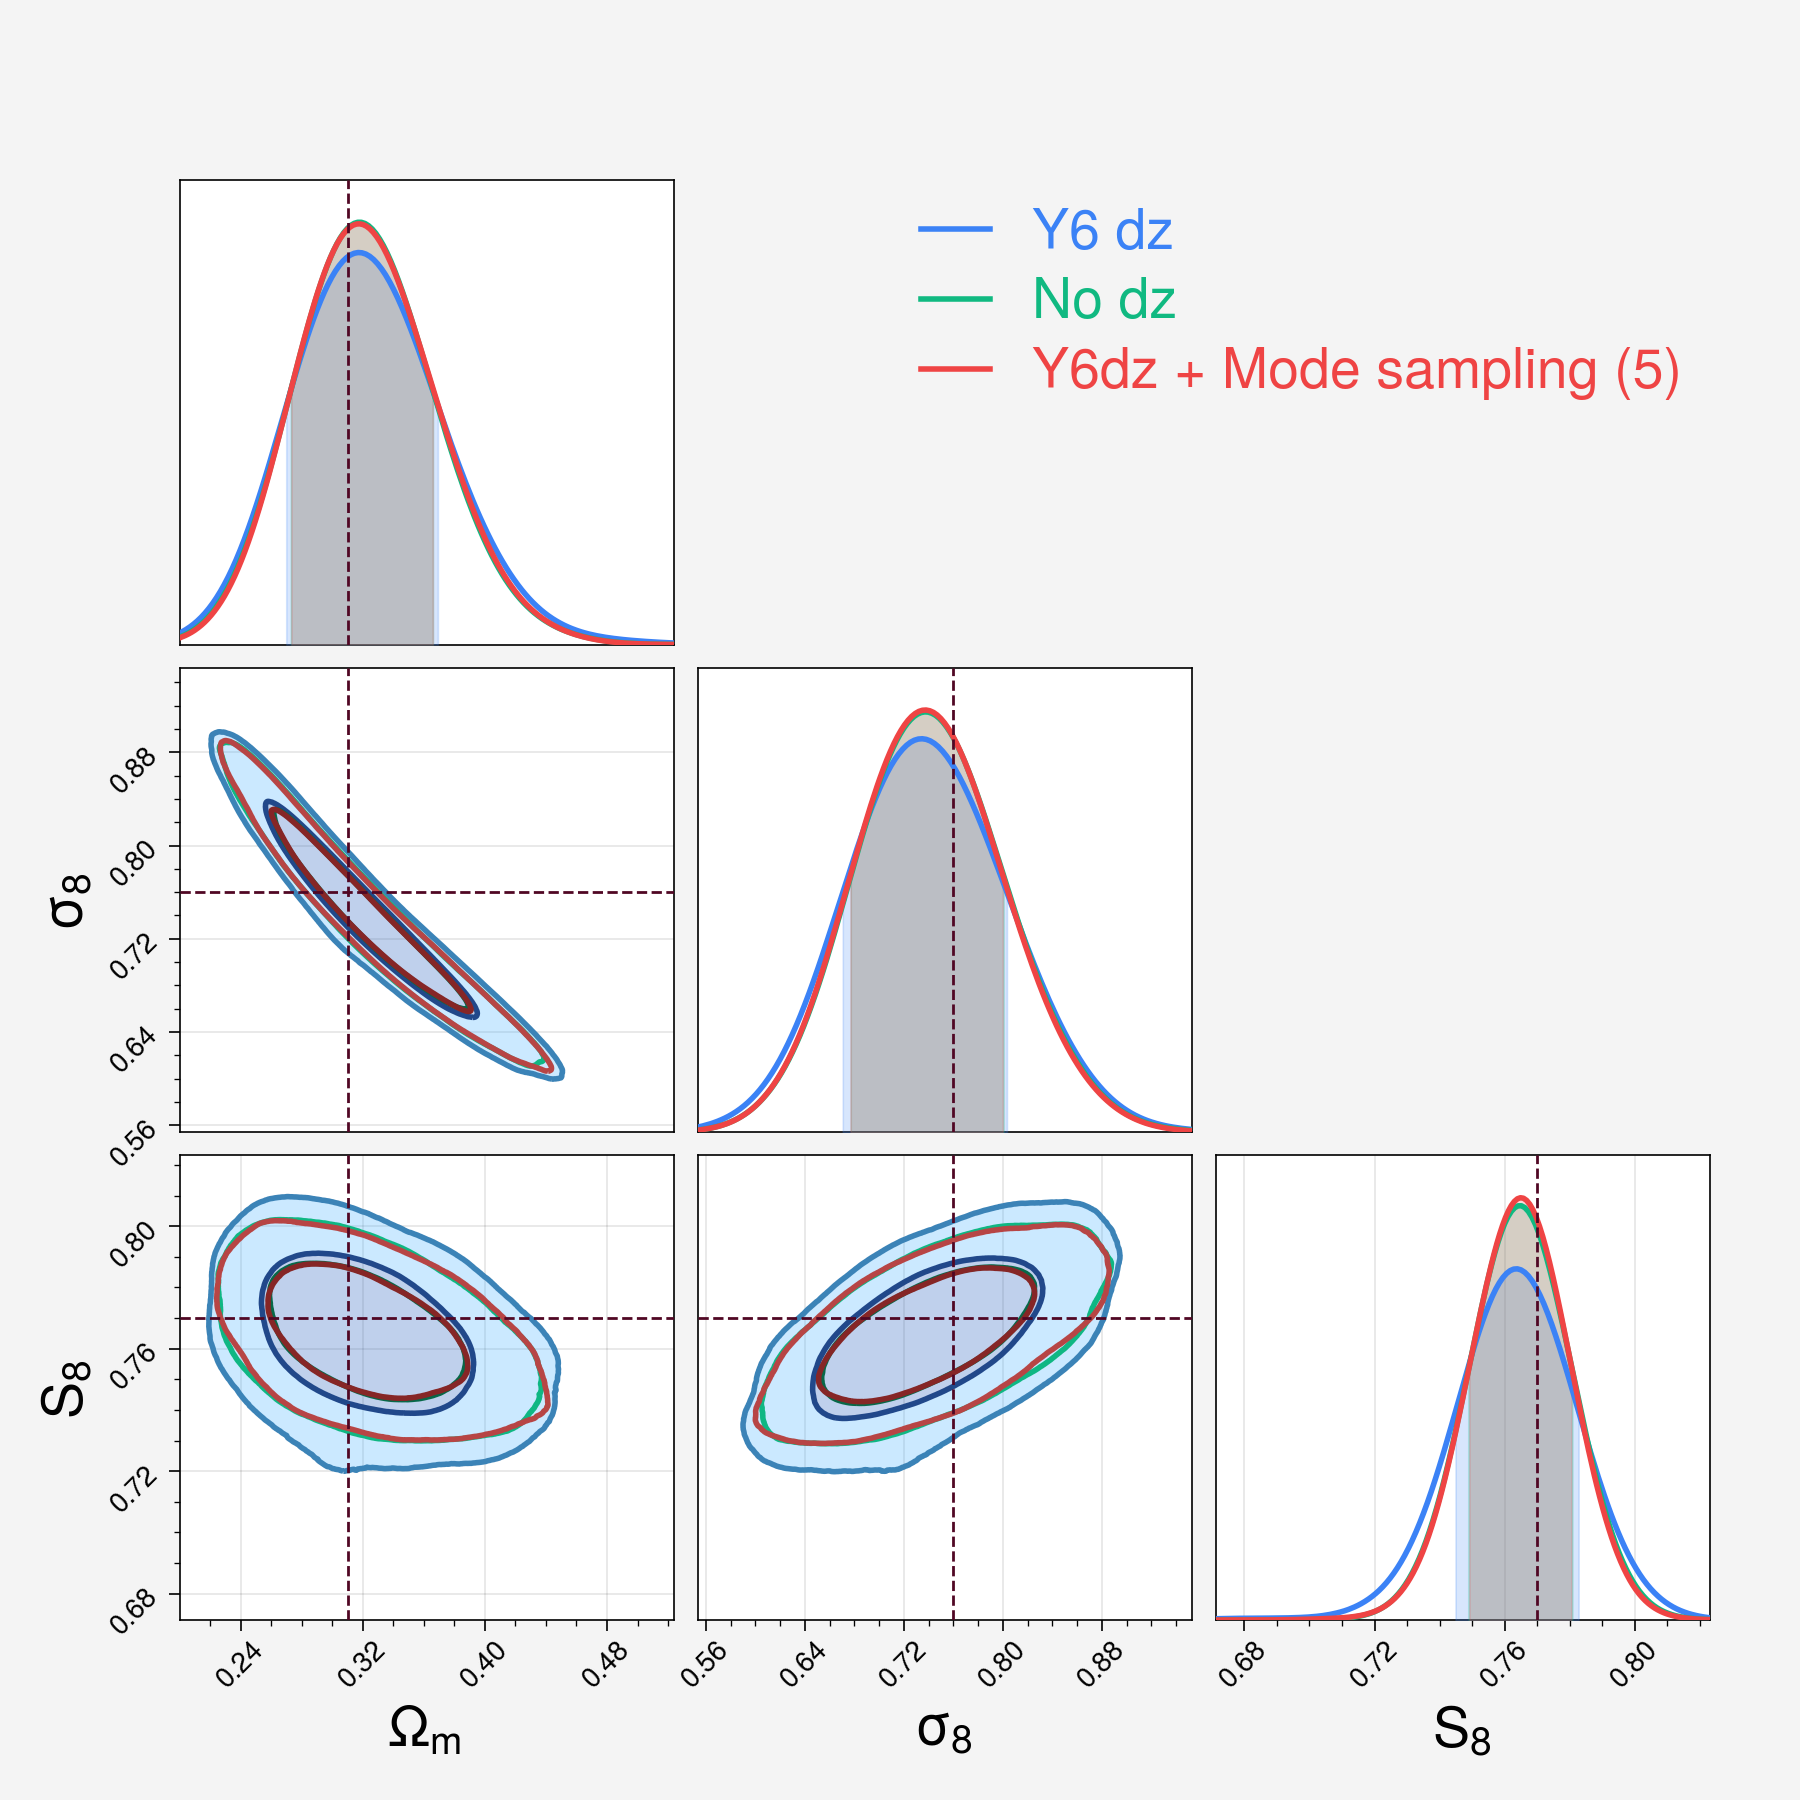

In [9]:
c = ChainConsumer()
labels = np.array(['Y6 dz', 'No dz', 'Y6dz + Mode sampling (5)'])
lstyles = ['-', '-', '-', '-', '-', '--']
Color = ['#e13102','#016e51','#ffa500','#12239e','k'] 
alphas = [0.3,0.,0.,0.,0.,0.] 
chains = [np.genfromtxt(filename_y6dz, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_nodz, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_mode_y6dz, names = True, deletechars='', case_sensitive='lower')] 
plot_chains(c, chains, labels, lstyles, alphas, Color, oms8=False, recenter=False, save=False)

\begin{table}
    \centering
    \caption{}
    \label{tab:model_params}
    \begin{tabular}{cccccc}
        \hline
		Model & $u_0$ & $u_1$ & $u_2$ & $u_3$ & $u_4$ \\ 
		\hline
		Mode sampling (5) & $0.000^{+0.017}_{-0.016}$ & $\left( 0.1^{+7.7}_{-8.1} \right) \times 10^{-3}$ & $\left( -0.2^{+6.1}_{-5.8} \right) \times 10^{-3}$ & $\left( 0.1\pm 5.7 \right) \times 10^{-3}$ & $\left( 0.0^{+3.4}_{-3.3} \right) \times 10^{-3}$ \\ 
		\hline
    \end{tabular}
\end{table}


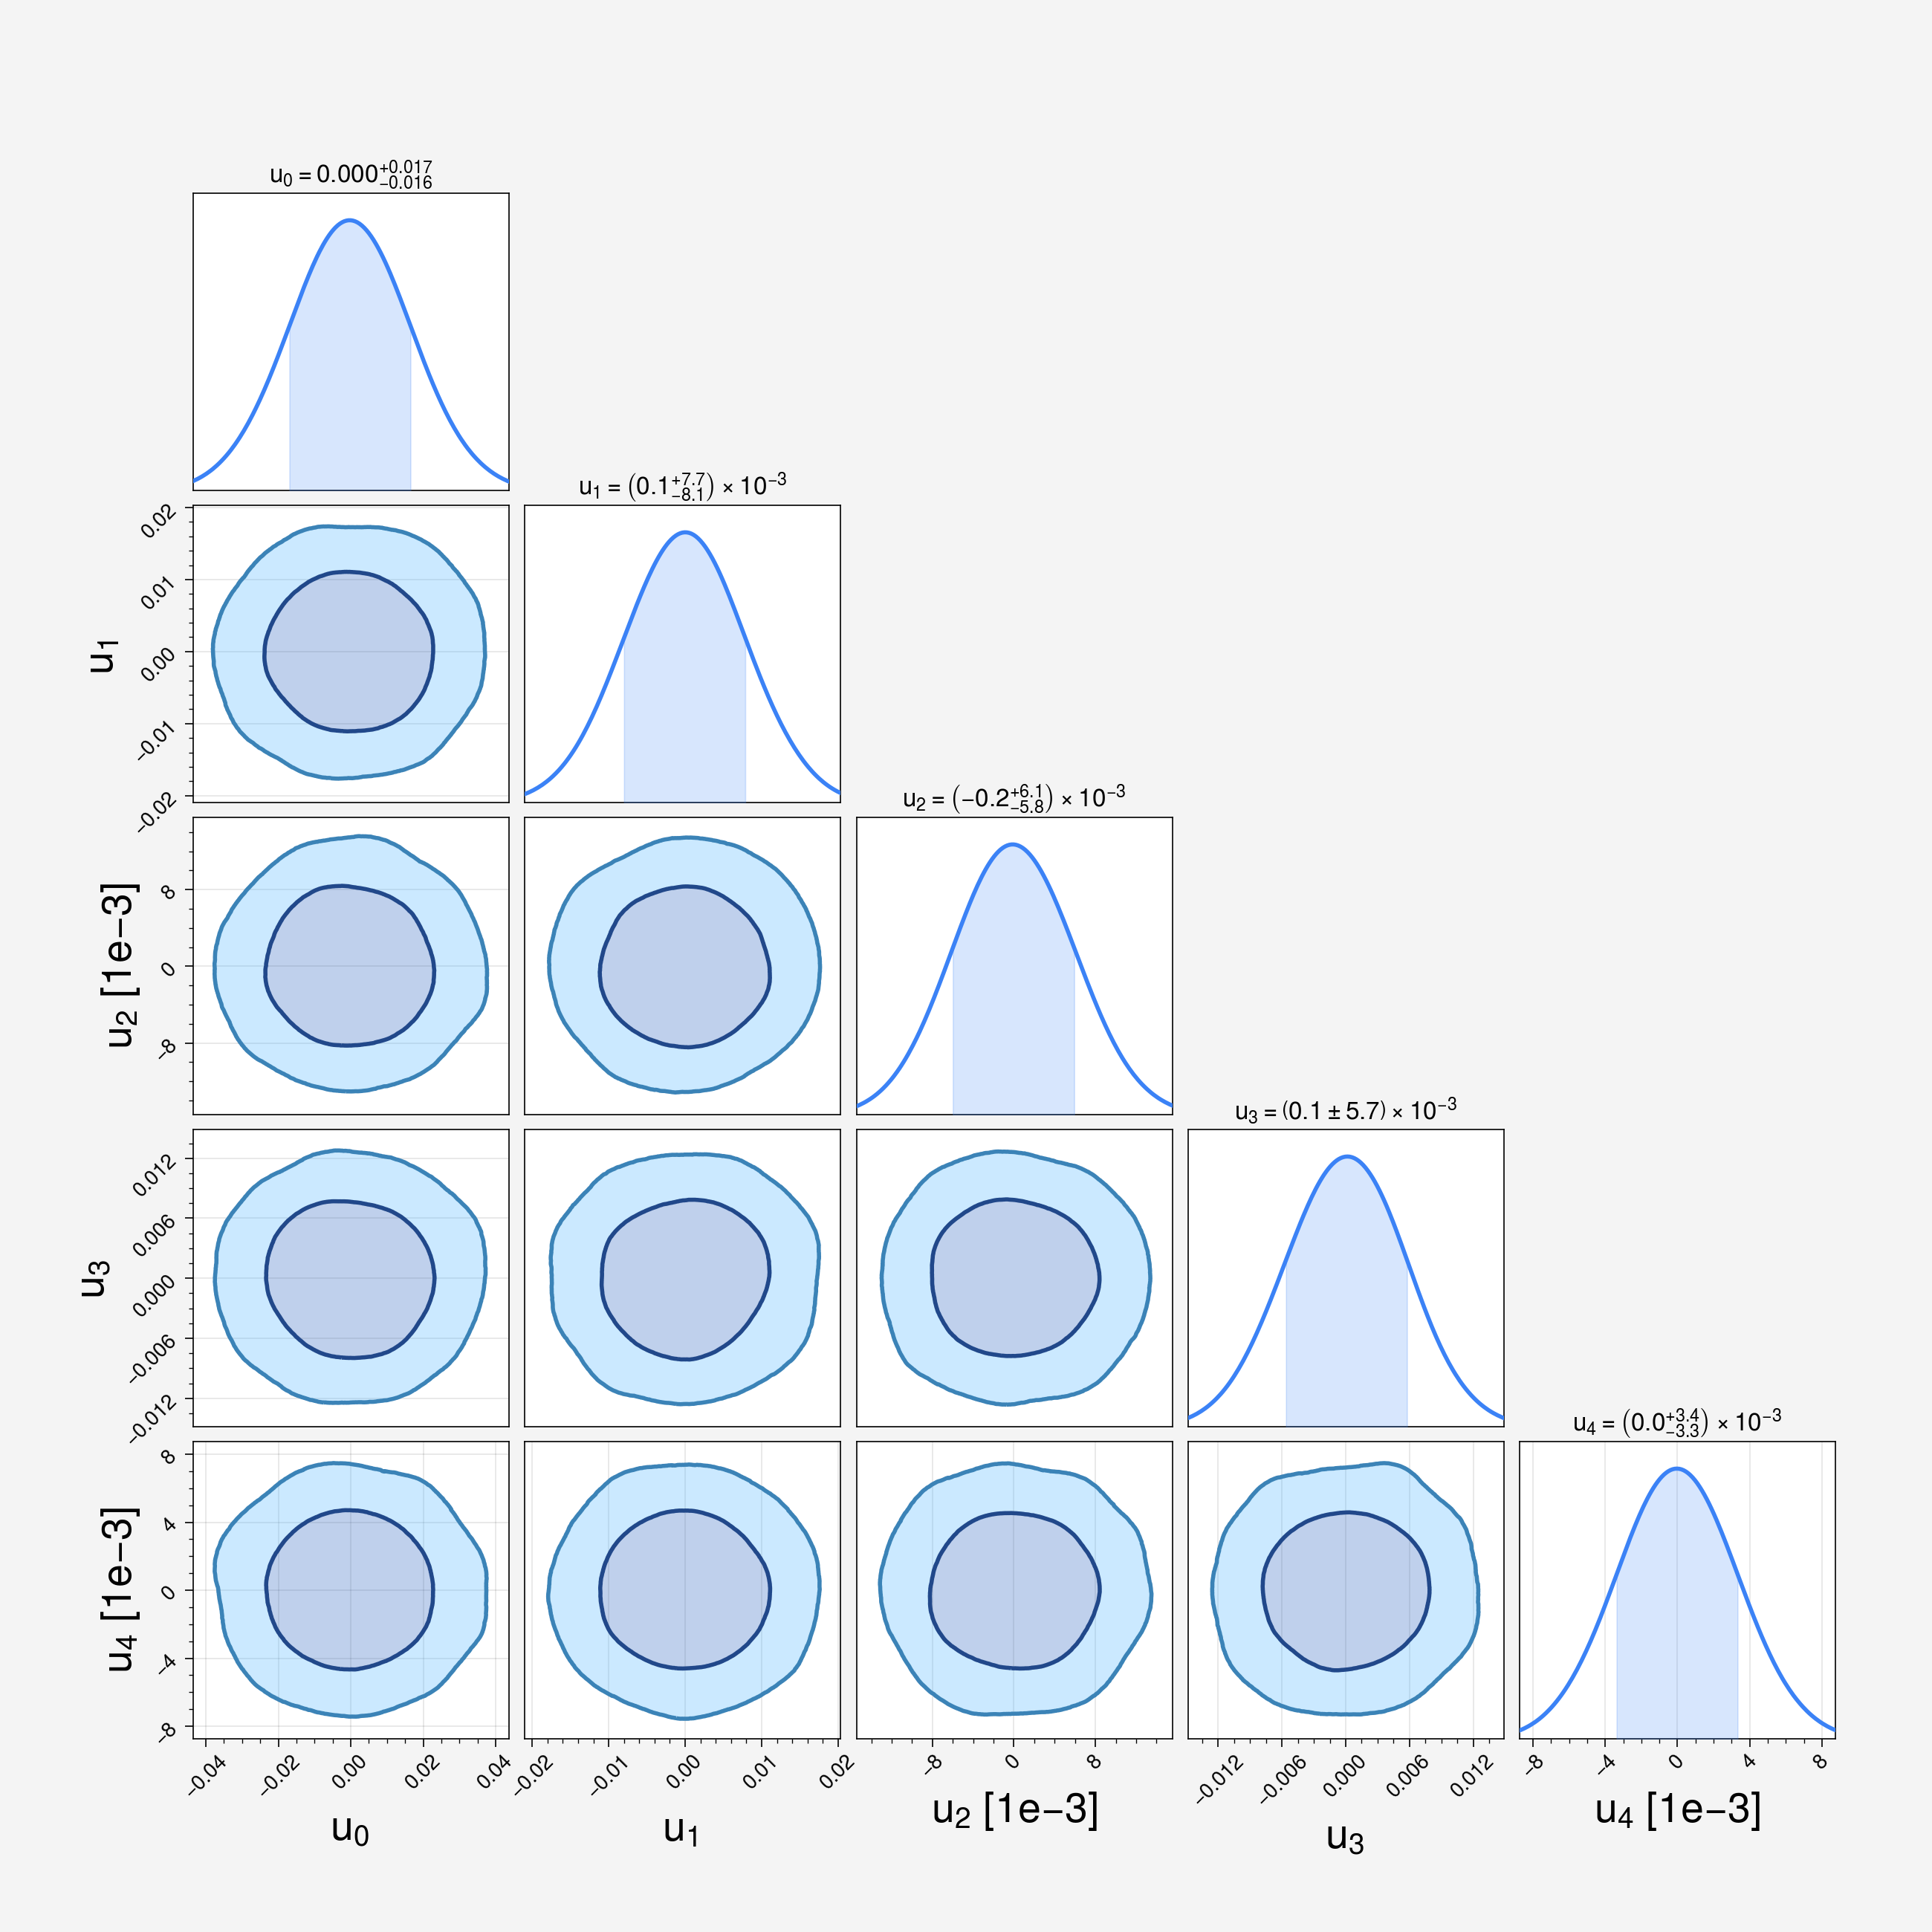

In [26]:
c = ChainConsumer()
labels = np.array(['Mode sampling (5)'])
lstyles = ['-', '-', '-', '-', '-', '--']
Color = ['#e13102','#016e51','#ffa500','#12239e','k'] 
alphas = [0.3,0.,0.,0.,0.,0.] 
chains = [np.genfromtxt(filename_mode, names = True, deletechars='', case_sensitive='lower')]
params = ['source_photoz_u--u_0', 'source_photoz_u--u_1', 'source_photoz_u--u_2', 
          'source_photoz_u--u_3', 'source_photoz_u--u_4', 'log_weight']
plot_chains_noncosmo(c, chains, params, labels, lstyles, alphas, Color, oms8=False, recenter=False, truth=False, save=False)

\begin{table}
    \centering
    \caption{}
    \label{tab:model_params}
    \begin{tabular}{cccccc}
        \hline
		Model & $u_0$ & $u_1$ & $u_2$ & $u_3$ & $u_4$ \\ 
		\hline
		Mode sampling (5) & $0.000^{+0.017}_{-0.016}$ & $\left( 0.1^{+7.7}_{-8.1} \right) \times 10^{-3}$ & $\left( -0.2^{+6.1}_{-5.8} \right) \times 10^{-3}$ & $\left( 0.1\pm 5.7 \right) \times 10^{-3}$ & $\left( 0.0^{+3.4}_{-3.3} \right) \times 10^{-3}$ \\ 
		Old Mode sampling (5) & $-0.001^{+0.086}_{-0.083}$ & $0.000^{+0.040}_{-0.039}$ & $0.000\pm 0.030$ & $0.000\pm 0.028$ & $0.000\pm 0.016$ \\ 
		\hline
    \end{tabular}
\end{table}


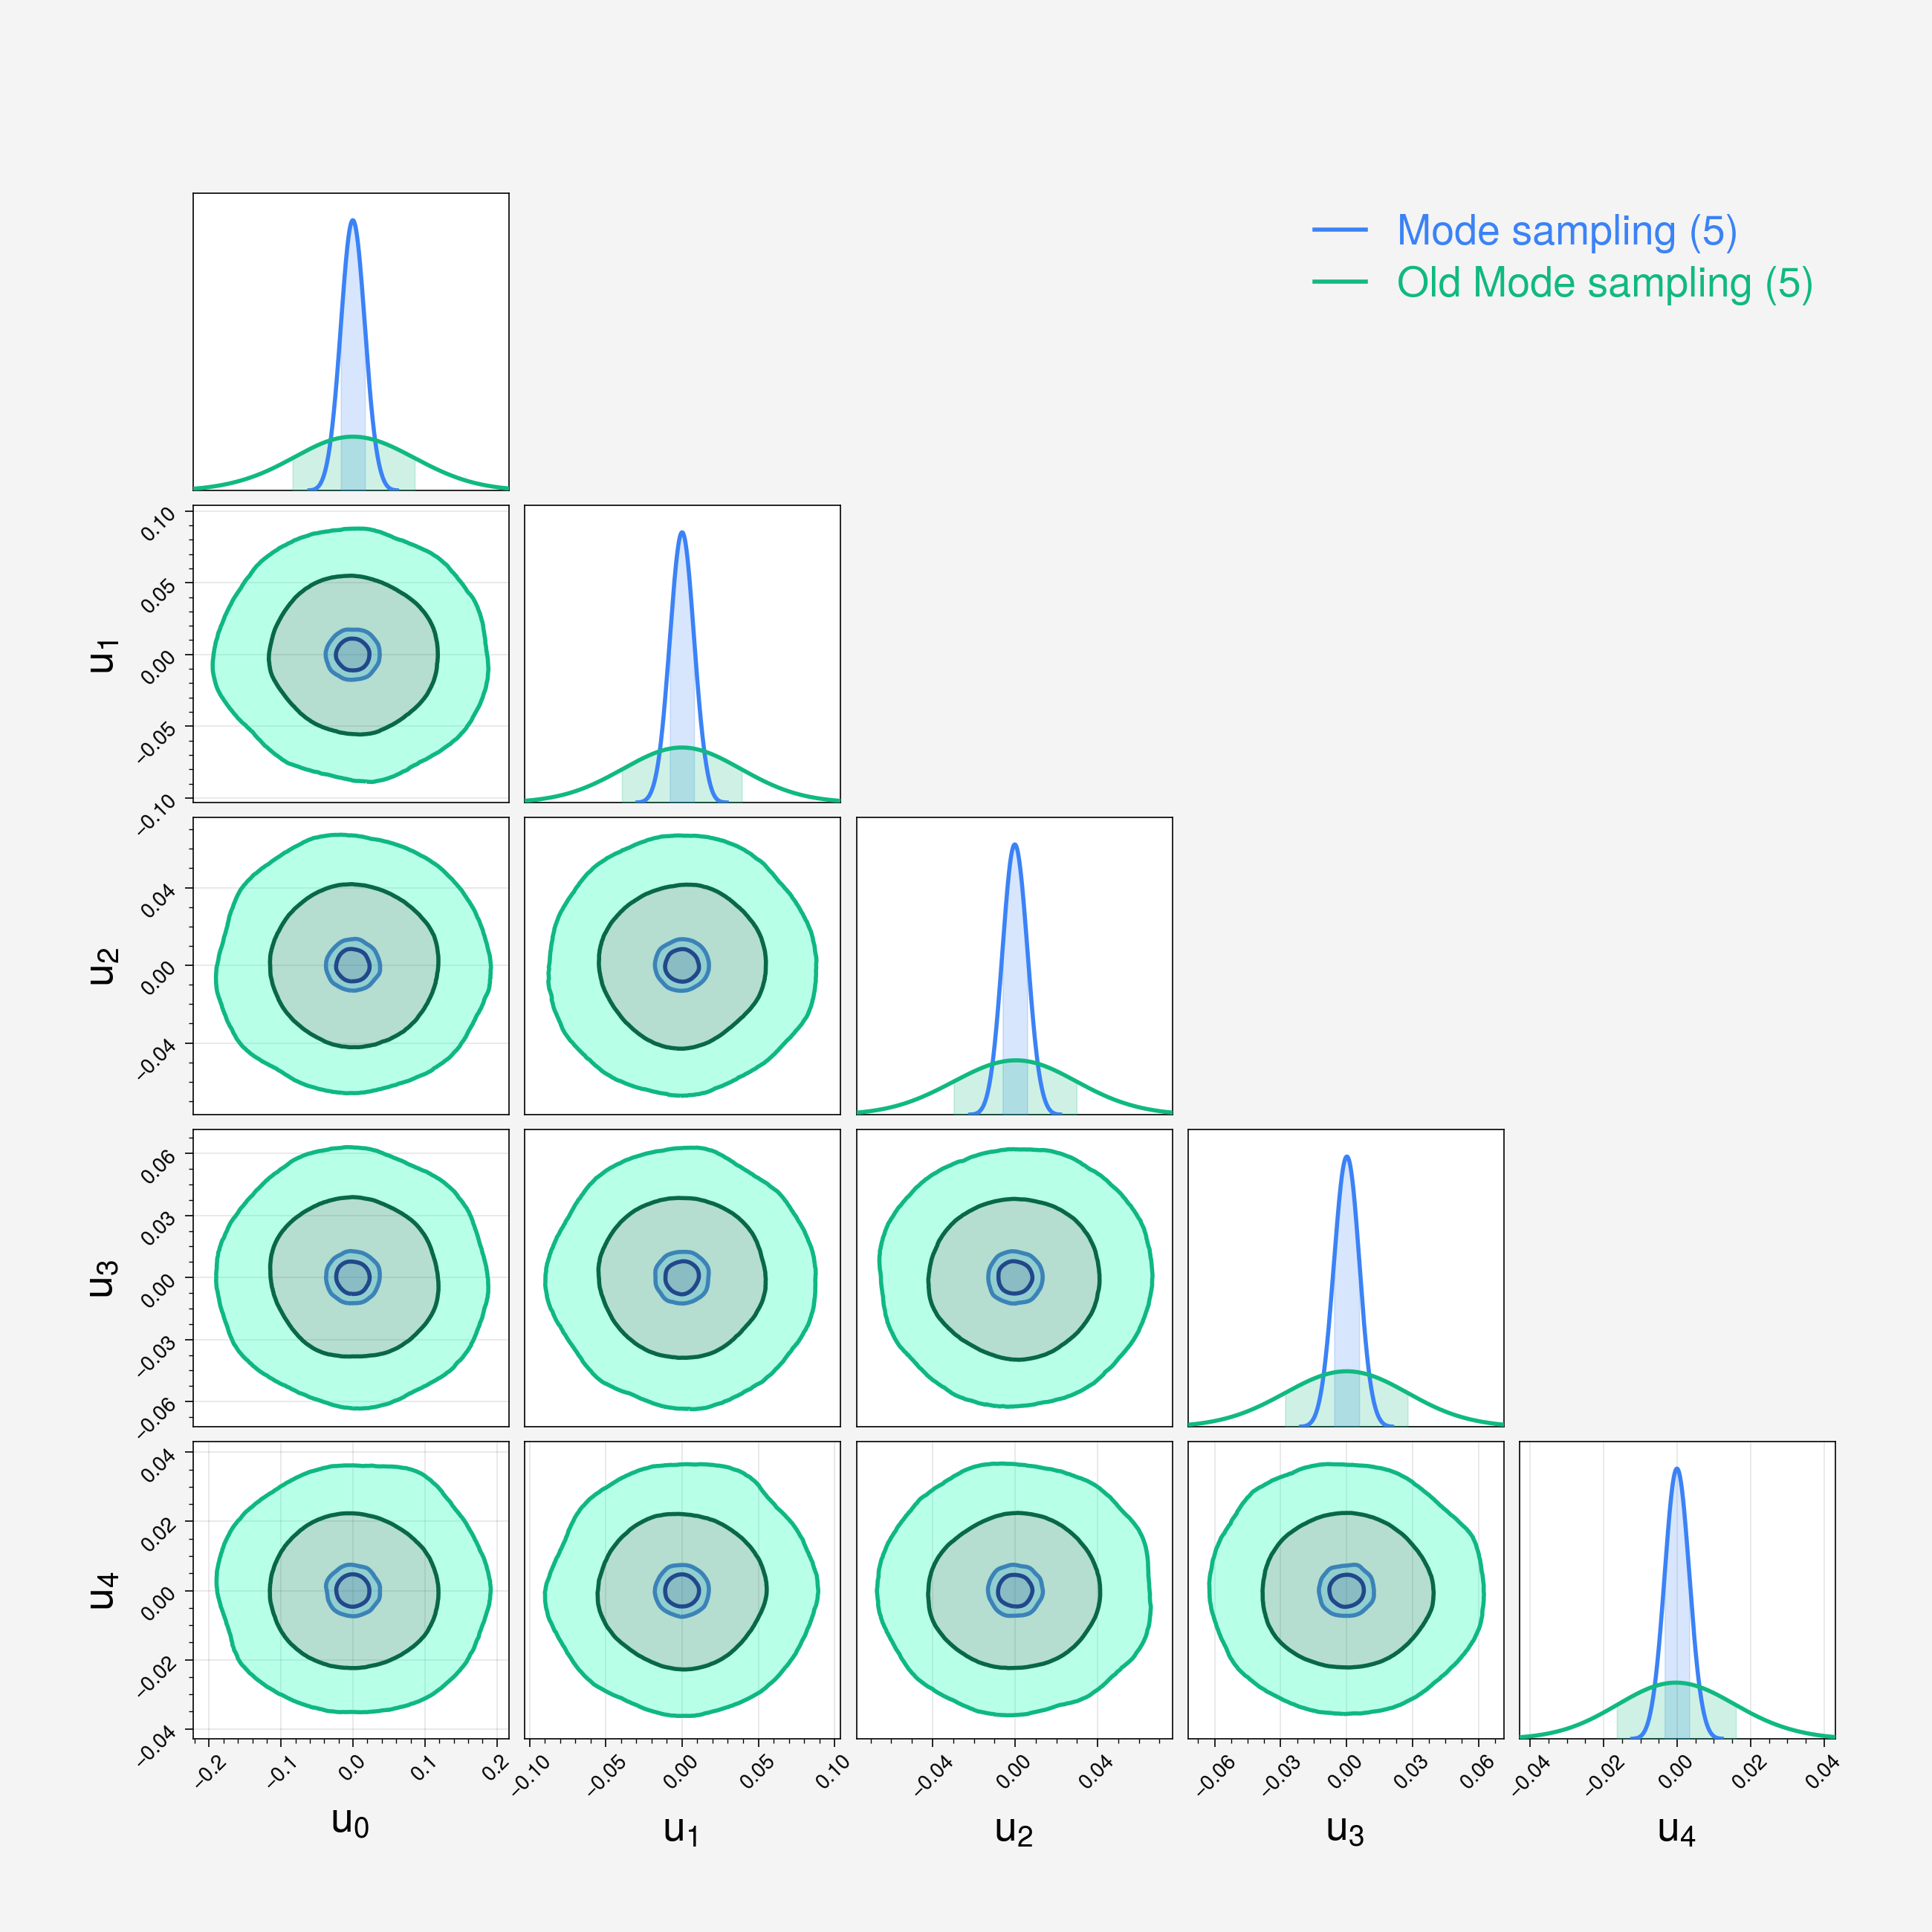

In [27]:
labels = np.array(['Old Mode sampling (5)'])
chains = [np.genfromtxt(filename_mode_old, names = True, deletechars='', case_sensitive='lower')]
params = ['source_5_unsmooth_coarse_photoz_u--u_0', 'source_5_unsmooth_coarse_photoz_u--u_1', 'source_5_unsmooth_coarse_photoz_u--u_2', 
          'source_5_unsmooth_coarse_photoz_u--u_3', 'source_5_unsmooth_coarse_photoz_u--u_4', 'log_weight']
plot_chains_noncosmo(c, chains, params, labels, lstyles, alphas, Color, oms8=False, recenter=False, truth=False, save=False)

## shear bias

In [3]:
path_chains_pz = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/pz/'
path_chains_m = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/shearbias/'
path_save = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER'

filename_y6dz = os.path.join(path_chains_pz,'y6dz/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_y6dz_nom = os.path.join(path_chains_m,'zerom/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')

\begin{table}
    \centering
    \caption{}
    \label{tab:model_params}
    \begin{tabular}{cccc}
        \hline
		Model & $\Omega_{{m}}$ & $\sigma_{8}$ & $S_{{8}}$ \\ 
		\hline
		Y3 m & $0.317^{+0.052}_{-0.048}$ & $0.734^{+0.069}_{-0.063}$ & $0.764\pm 0.019$ \\ 
		No m & $0.317^{+0.053}_{-0.047}$ & $0.736^{+0.066}_{-0.065}$ & $0.763\pm 0.018$ \\ 
		\hline
    \end{tabular}
\end{table}


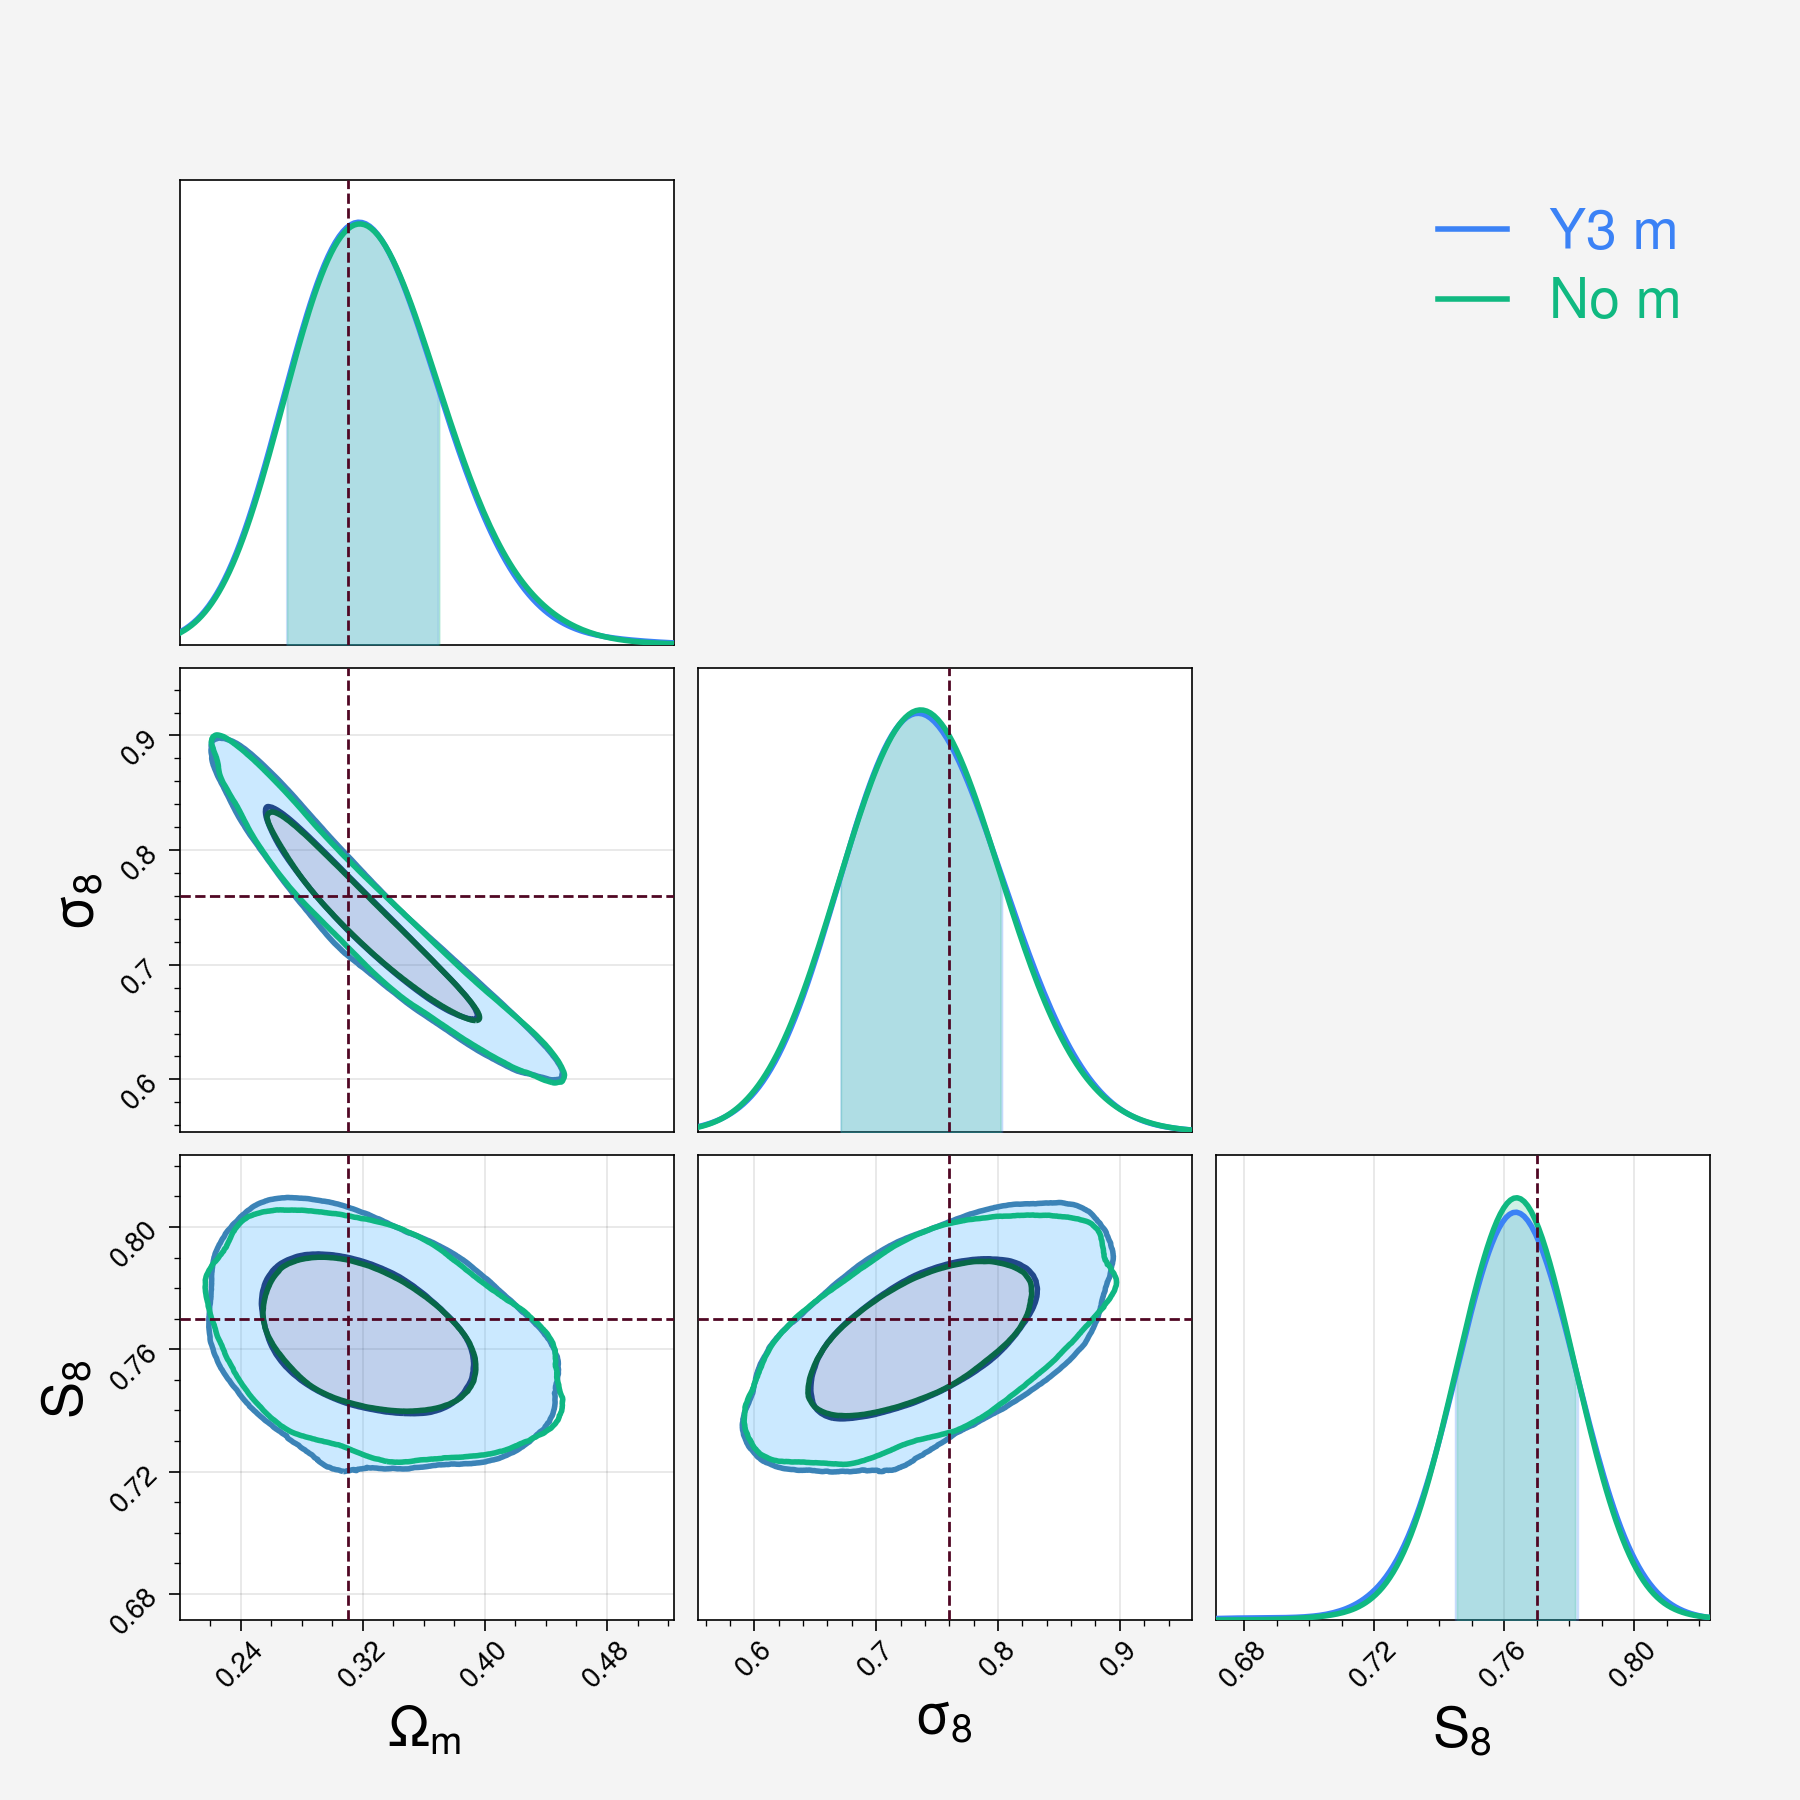

In [4]:
c = ChainConsumer()
labels = np.array(['Y3 m', 'No m'])
lstyles = ['-', '-']
Color = ['#e13102','#016e51'] 
alphas = [0.3,0.] 
chains = [np.genfromtxt(filename_y6dz, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_y6dz_nom, names = True, deletechars='', case_sensitive='lower'),] 
plot_chains(c, chains, labels, lstyles, alphas, Color, recenter=False)

## No cuts

In [25]:
path_chains = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/nocuts/'
path_save = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER'

filename_nocuts_y3dz = os.path.join(path_chains,'y3dz/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_nocuts.ini.txt')
filename_nocuts_y6dz = os.path.join(path_chains,'y6dz/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_nocuts.ini.txt')

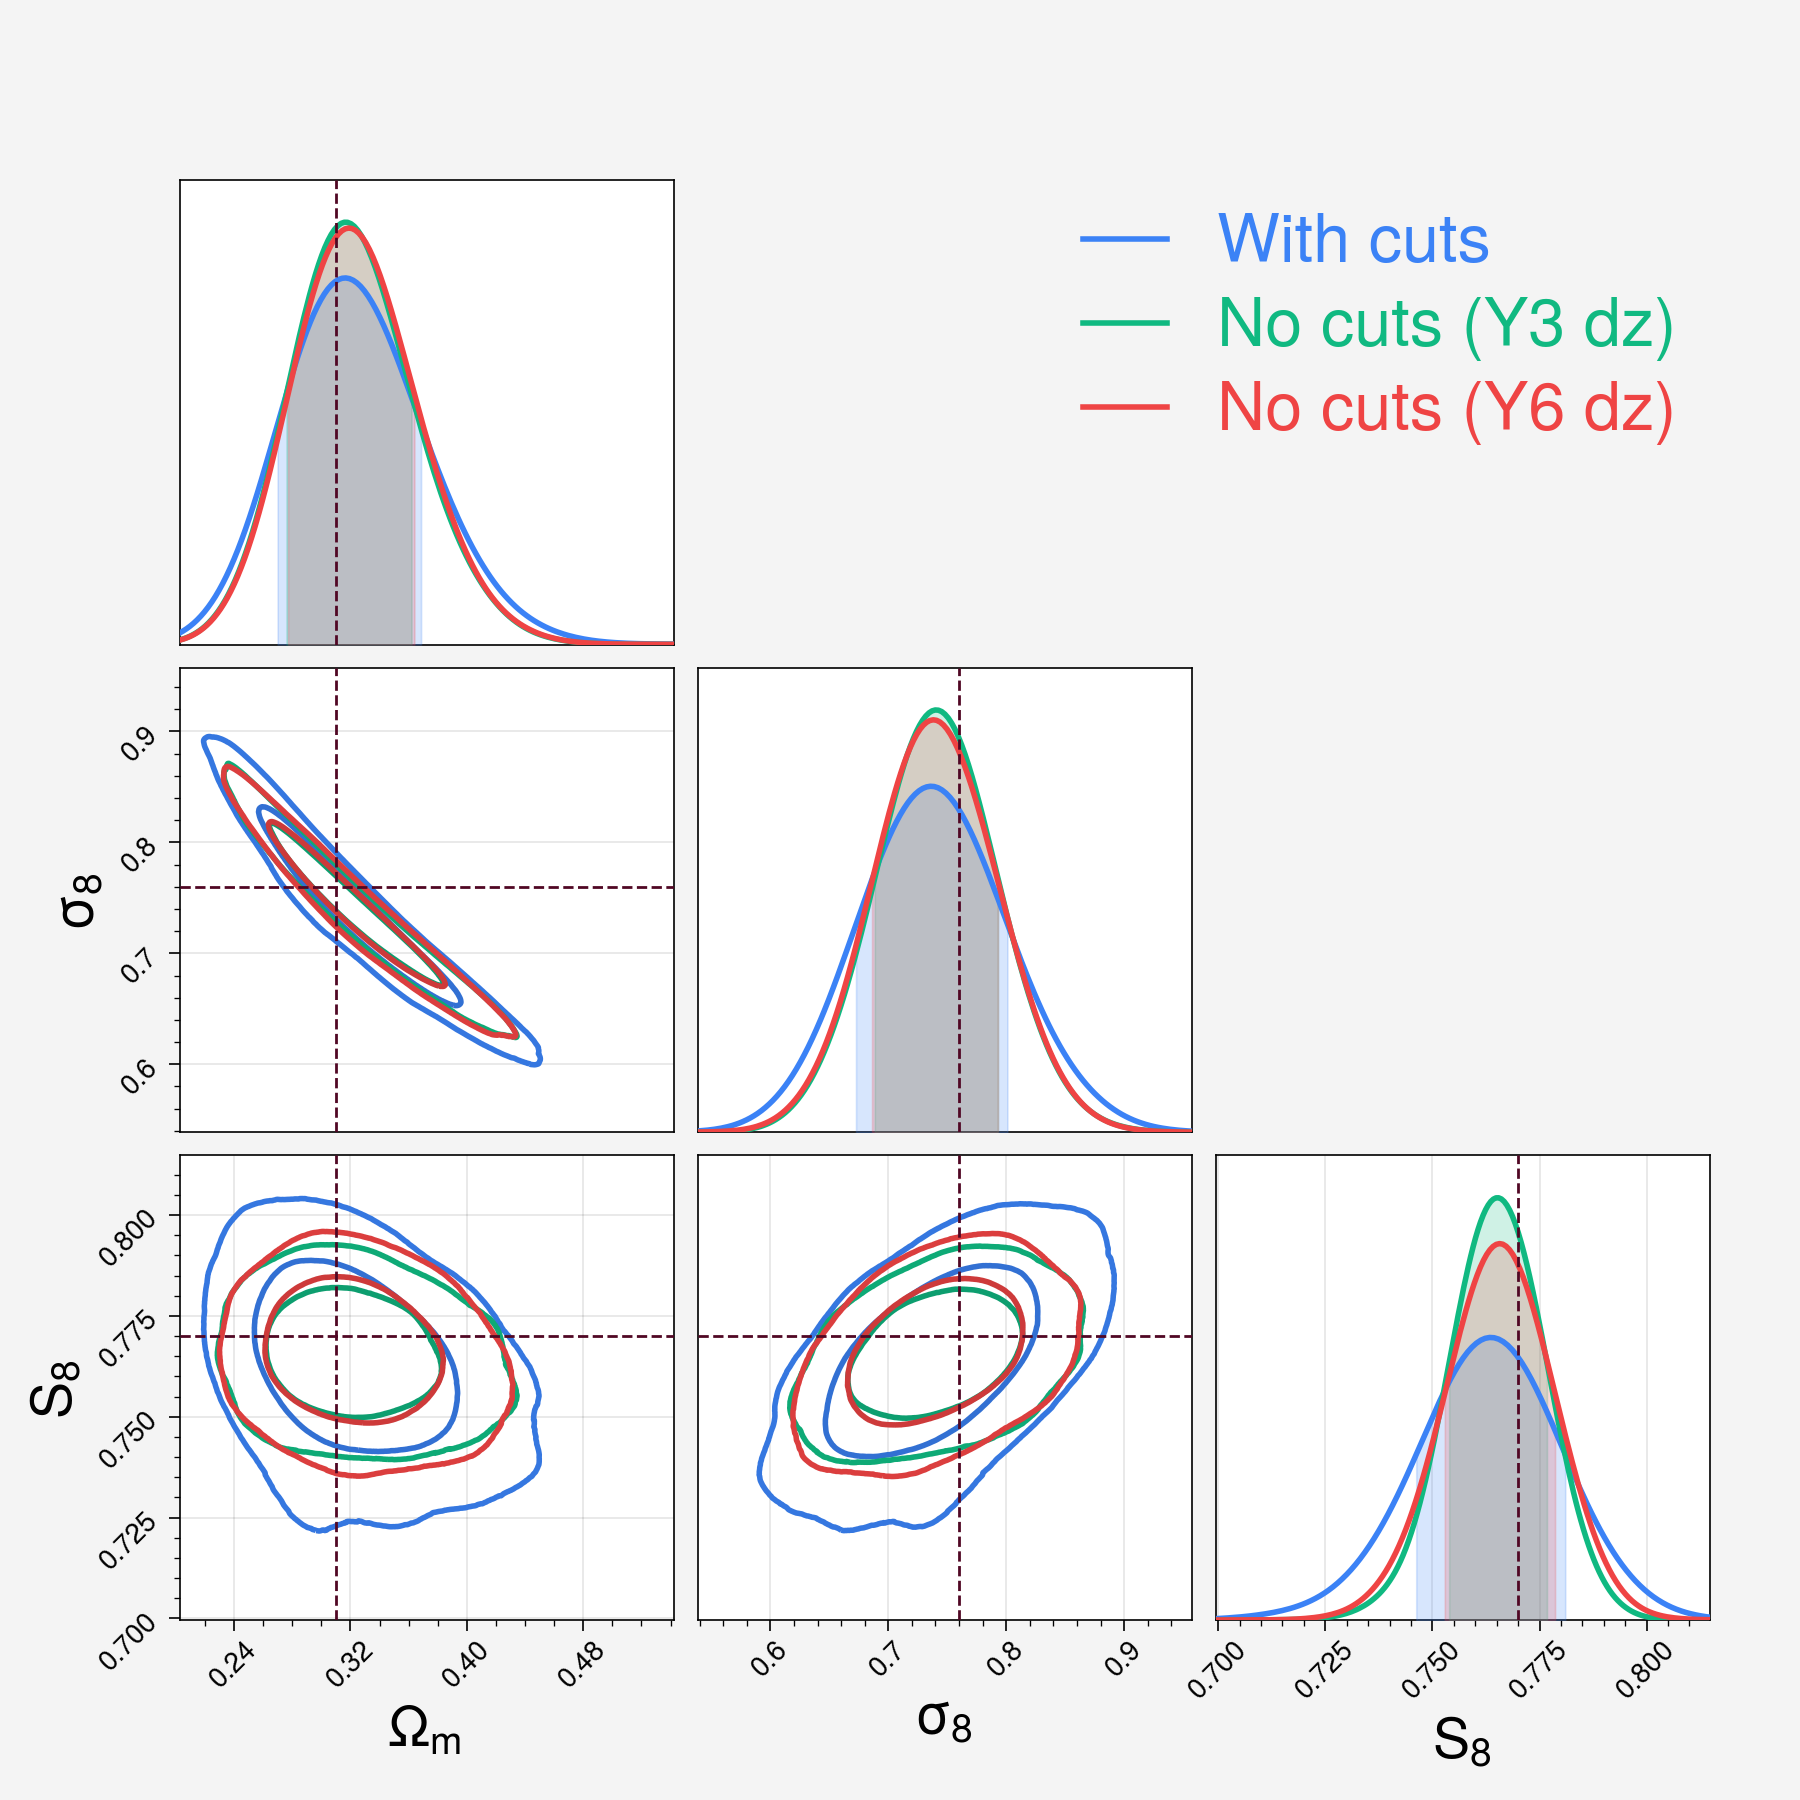

In [26]:
c = ChainConsumer()
labels = np.array(['With cuts', 'No cuts (Y3 dz)', 'No cuts (Y6 dz)'])
chains = [np.genfromtxt(filename_y3dz, names = True, deletechars='', case_sensitive='lower'),  
          np.genfromtxt(filename_nocuts_y3dz, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_nocuts_y6dz, names = True, deletechars='', case_sensitive='lower')] 
plot_chains(c, chains, labels)

## No sys

In [14]:
path_chains_nosys = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/nosys/'
path_save = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/'

filename_y6 = os.path.join(path_chains_nosys,'chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_nocuts.ini.txt')
filename_desy3fixsys = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/chain_1x2_fixsys_allscales_ML.txt'
filename_desy3fid = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/chain_1x2pt_lcdm_SR_maglim.txt'
filename_desy3opt = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/chain_1x2agg_NLA_ML.txt'

\begin{table}
    \centering
    \caption{}
    \label{tab:model_params}
    \begin{tabular}{ccc}
        \hline
		Model & $S_{{8}}$ & $\Omega_{{m}}$ \\ 
		\hline
		Y6 dz & $0.000\pm 0.019$ & $-0.007^{+0.052}_{-0.048}$ \\ 
		Y6 No Sys. & $\left( 0.6^{+8.0}_{-8.5} \right) \times 10^{-3}$ & $-0.003^{+0.036}_{-0.034}$ \\ 
		Y3 Fid SC+TATT & $0.000\pm 0.027$ & $-0.012^{+0.065}_{-0.055}$ \\ 
		Y3 Opt+NLA & $-0.001\pm 0.019$ & $-0.005^{+0.055}_{-0.054}$ \\ 
		Y3 No Sys. & $0.000\pm 0.011$ & $-0.007^{+0.054}_{-0.048}$ \\ 
		\hline
    \end{tabular}
\end{table}


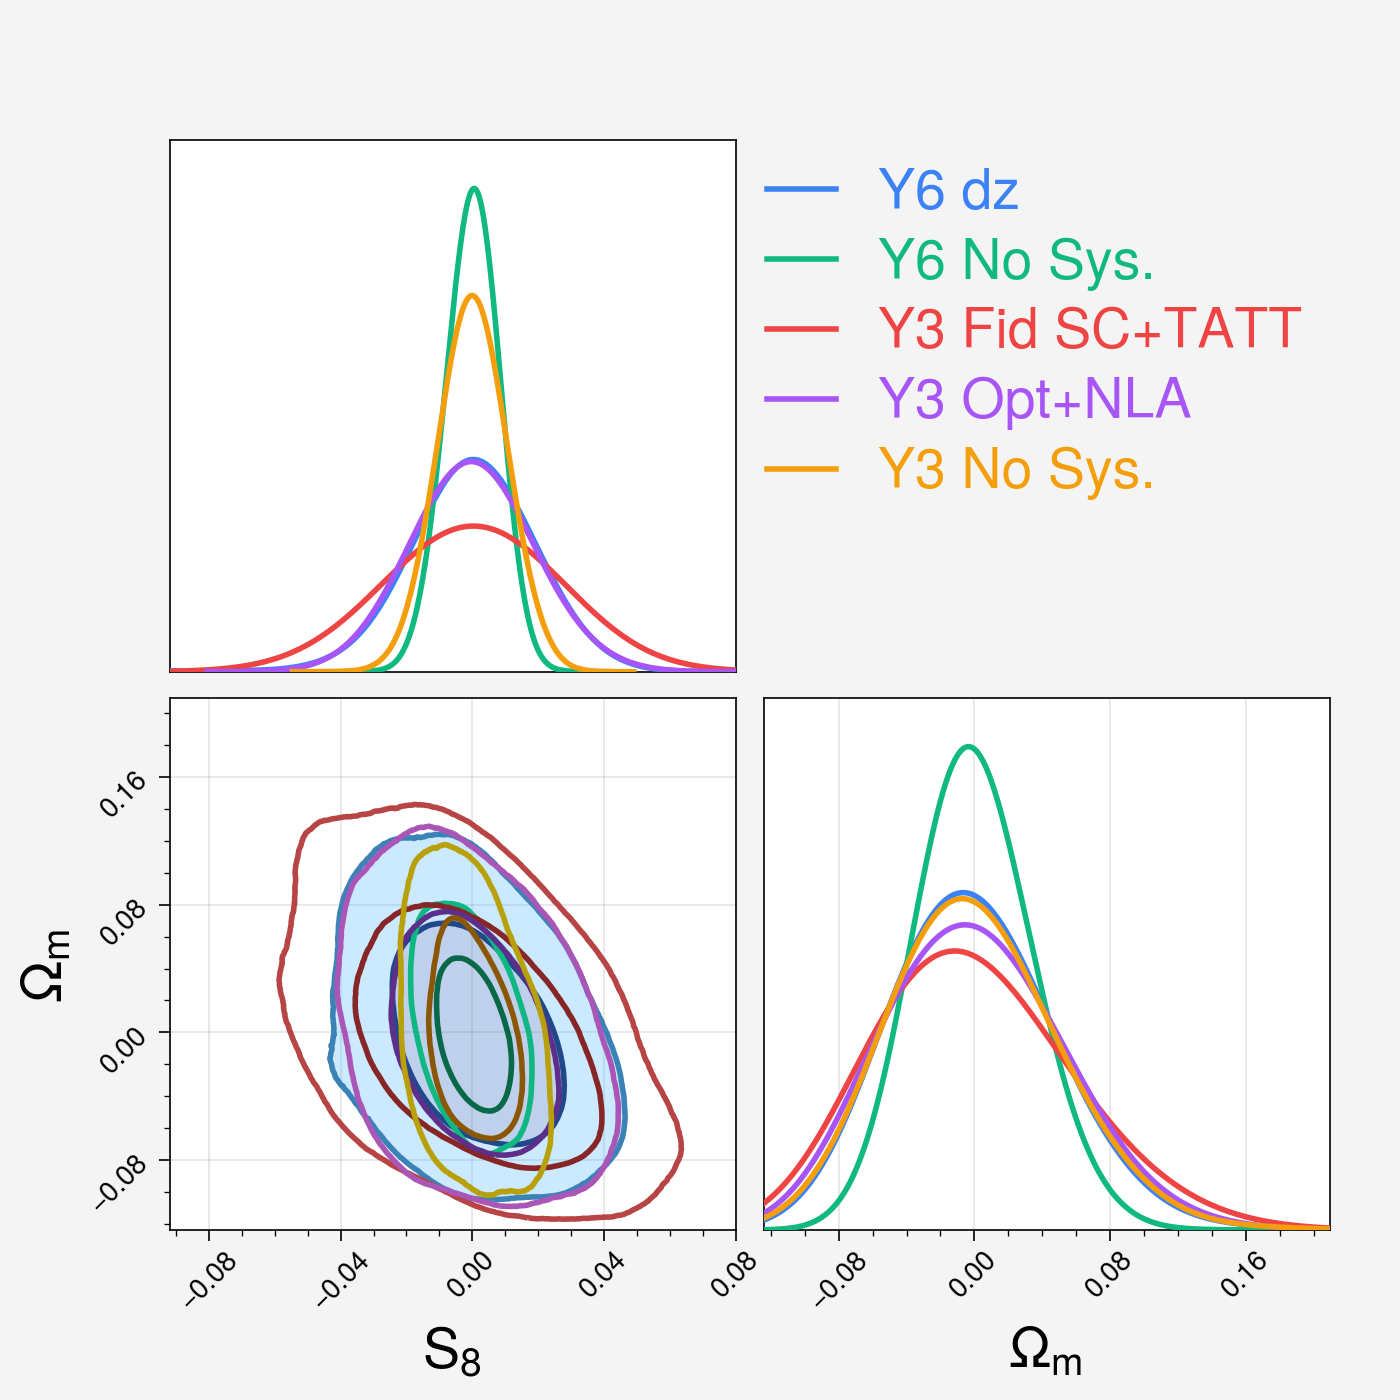

In [15]:
c = ChainConsumer()
labels = np.array(['Y6 dz', 'Y6 No Sys.', 'Y3 Fid SC+TATT', 'Y3 Opt+NLA', 'Y3 No Sys.'])
lstyles = ['-', '-', '-', '-', '-', '--']
Color = ['#e13102','#016e51','#ffa500','#12239e','k'] 
alphas = [0.3,0.,0.,0.,0.,0.] 
chains = [np.genfromtxt(filename_y6dz, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_y6, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_desy3fid, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_desy3opt, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_desy3fixsys, names = True, deletechars='', case_sensitive='lower')] 
plot_chains(c, chains, labels, lstyles, alphas, Color, oms8=True, recenter=True, truth=False, save=True, outdir=path_save+'y6headline_nosys_y3headline_oms8.pdf')

## Compare PSF sys with Calvin

In [16]:
path_chains_PSF = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/PSF'

filename_masa = os.path.join(path_chains_PSF,'chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0_max3sigPSFcontaminated.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_calvin = os.path.join(path_chains_PSF,'calvin/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0_max3sigPSFcontaminated.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_maxPSFnocuts = os.path.join(path_chains_PSF,'calvin/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0_max3sigPSFcontaminated.fits.scales_1x2pt_chi2_3.50_v5_NOCUTS_NEWREDSHIFTS.ini.txt')
filename_baseline_nocuts = os.path.join(path_chains_PSF,'calvin/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5_NOCUTS_NEWREDSHIFTS.ini.txt')

\begin{table}
    \centering
    \caption{}
    \label{tab:model_params}
    \begin{tabular}{cccc}
        \hline
		Model & $\Omega_{{m}}$ & $\sigma_{8}$ & $S_{{8}}$ \\ 
		\hline
		Max PSF (with cuts) & $0.313^{+0.050}_{-0.045}$ & $0.737^{+0.064}_{-0.060}$ & $0.761^{+0.018}_{-0.017}$ \\ 
		Max PSF (w/o cuts) & $0.305^{+0.042}_{-0.040}$ & $0.760\pm 0.053$ & $0.769\pm 0.011$ \\ 
		Baseline (no cuts) & $0.318^{+0.044}_{-0.041}$ & $0.741^{+0.051}_{-0.052}$ & $0.765^{+0.012}_{-0.011}$ \\ 
		\hline
    \end{tabular}
\end{table}


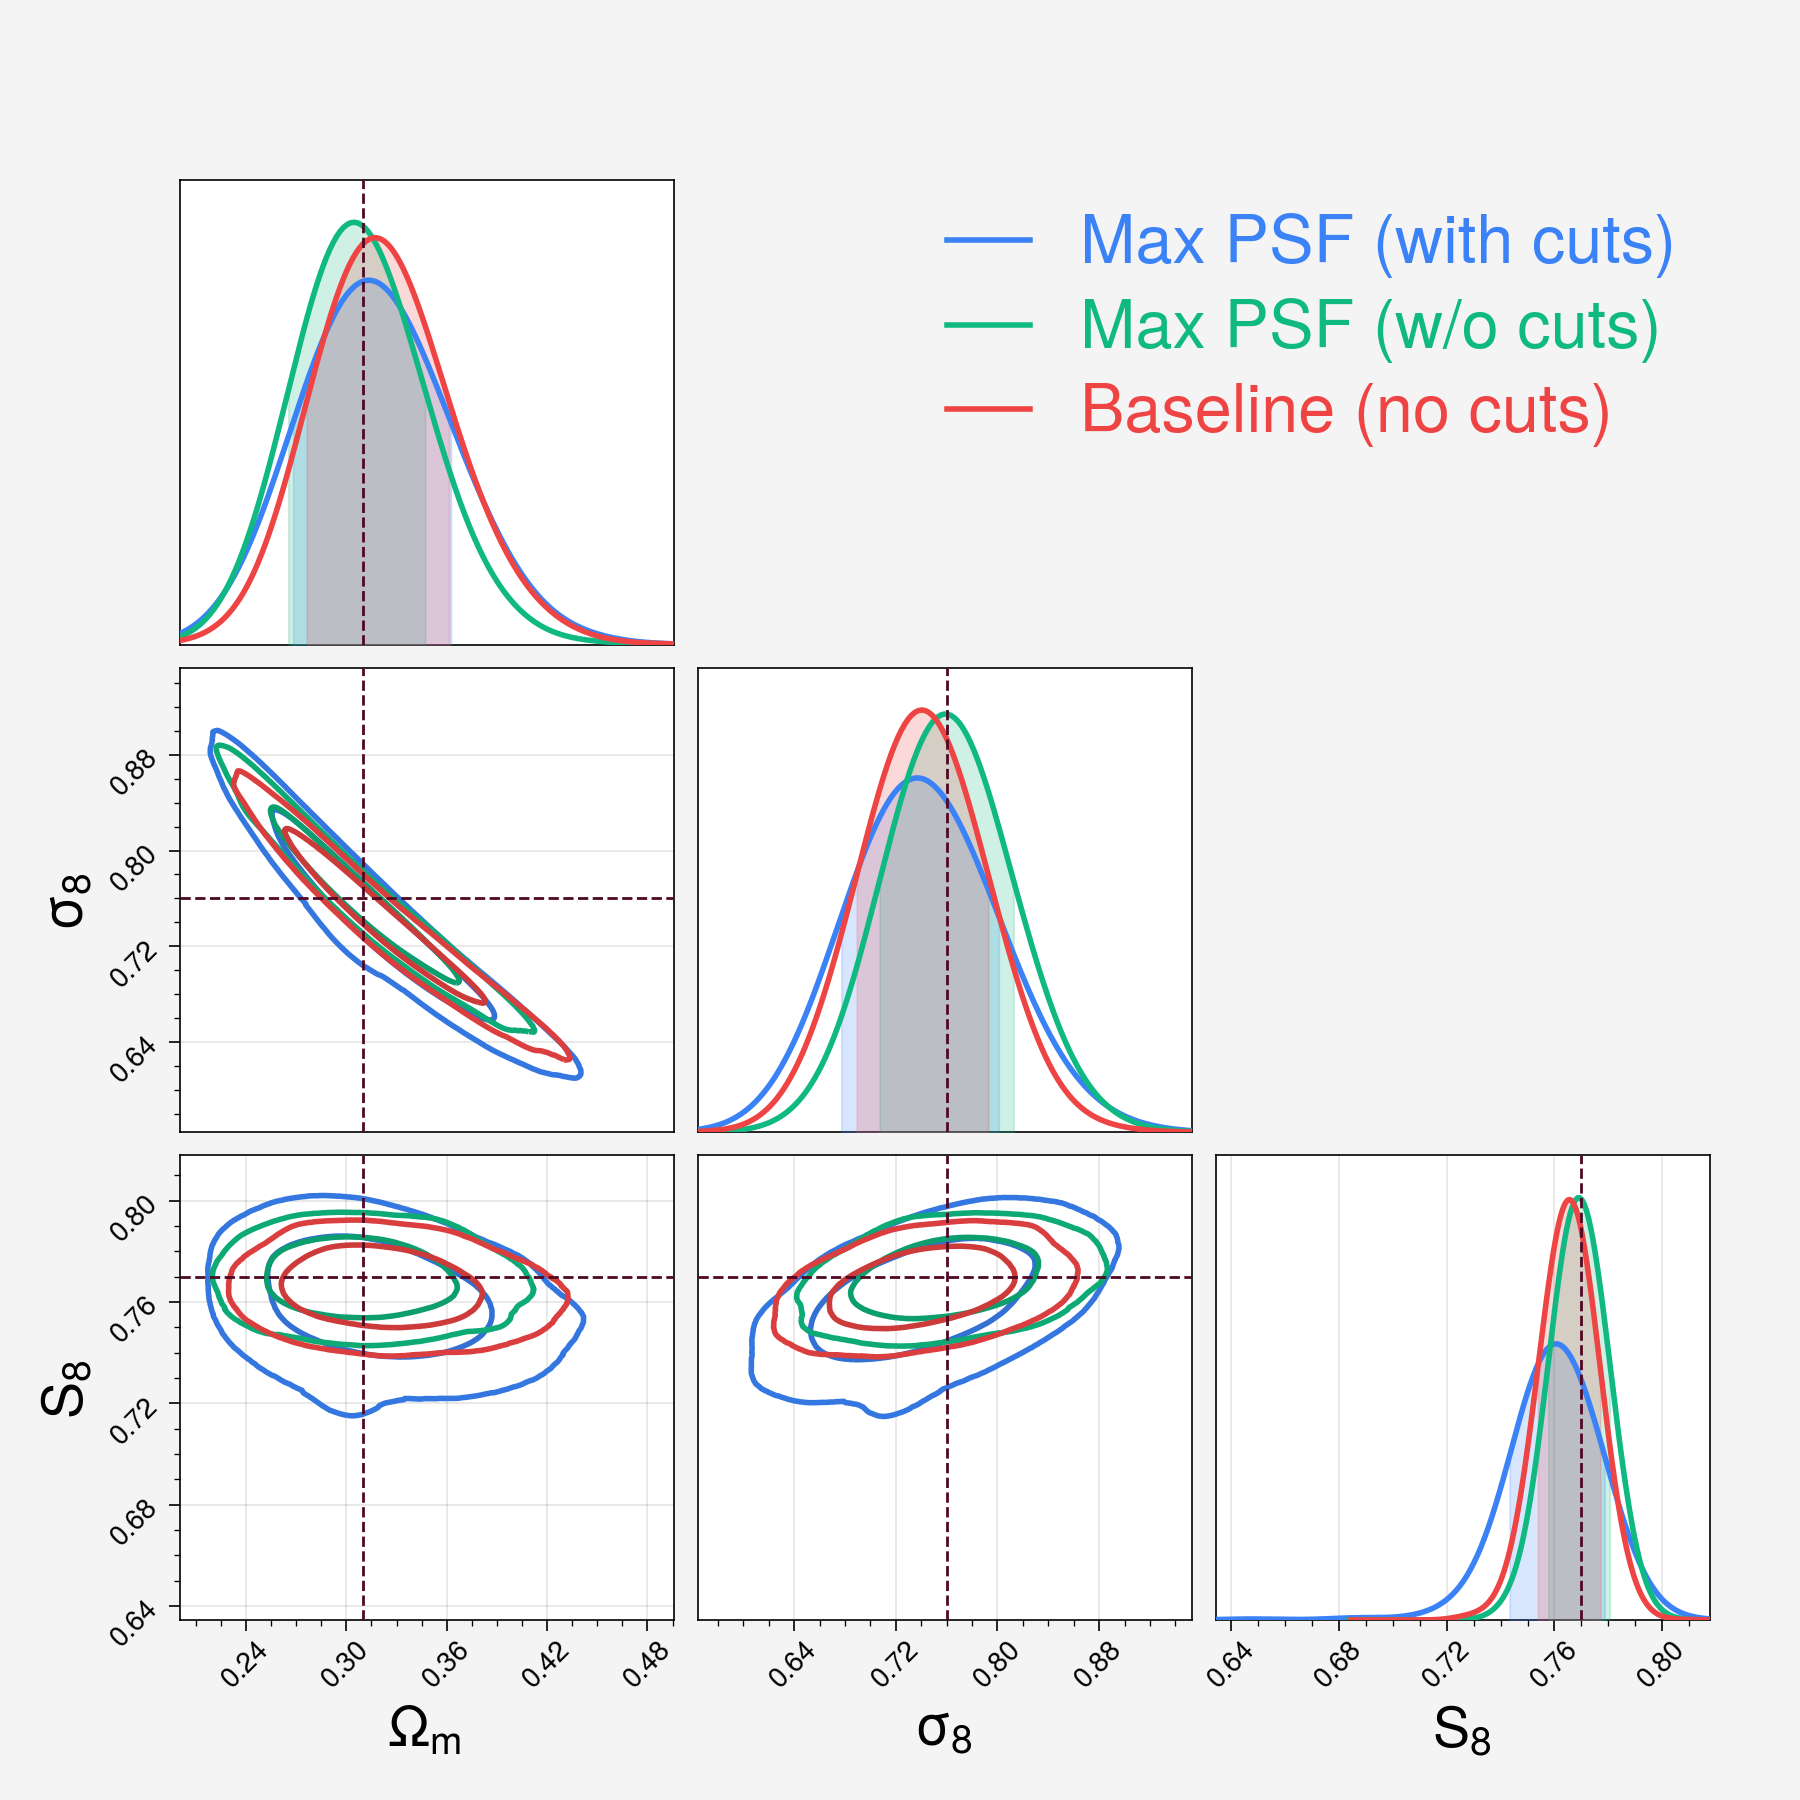

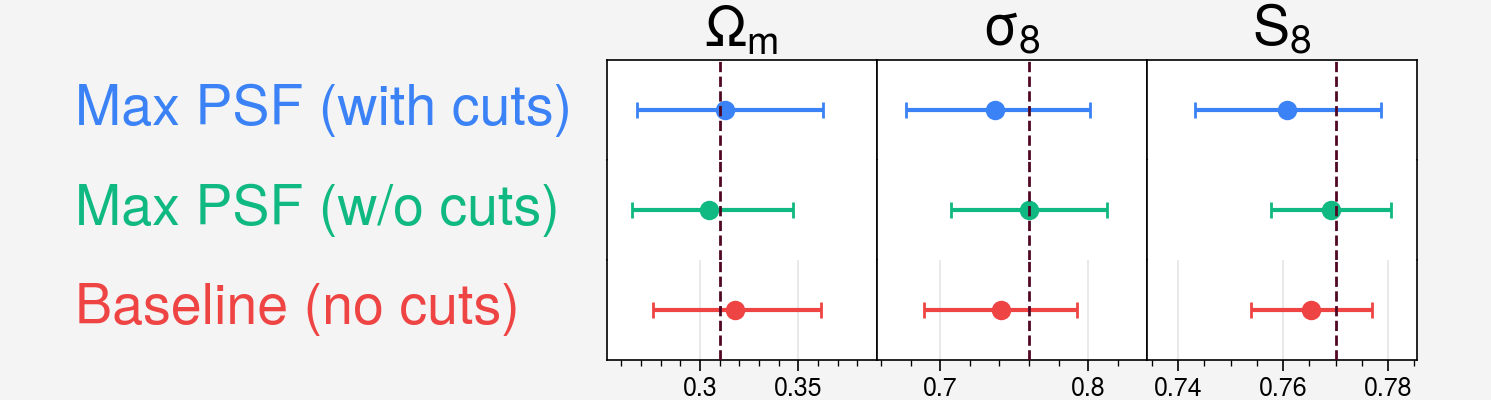

In [8]:
c = ChainConsumer()
labels = np.array(['Max PSF (with cuts)', 'Max PSF (w/o cuts)', 'Baseline (no cuts)'])
chains = [np.genfromtxt(filename_calvin, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_maxPSFnocuts, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_baseline_nocuts, names = True, deletechars='', case_sensitive='lower')] 
plot_chains(c, chains, labels, recenter=True)

file has log weight column
file has log weight column
Removed no burn in


Removed no burn in
0.7687014827139967 0.768086033800399
0.7652469109593335 0.7658272878490862


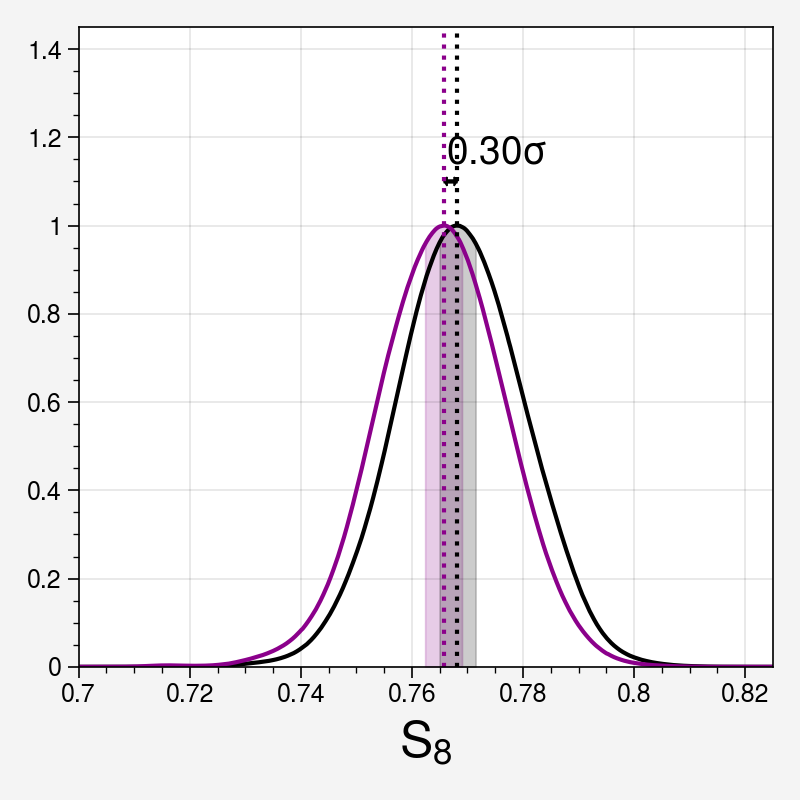

Removed no burn in
Removed no burn in
0.31 0.3174183265594146 0.30635662060230634
0.77 0.7663492277664511 0.7688380461124844
Optimization terminated successfully.
         Current function value: 0.000138
         Iterations: 16
         Function evaluations: 32
[0.0696875]
Optimization terminated successfully.
         Current function value: 0.000035
         Iterations: 18
         Function evaluations: 36
[0.1045]
Optimization terminated successfully.
         Current function value: 0.000142
         Iterations: 16
         Function evaluations: 32
[0.070375]
Optimization terminated successfully.
         Current function value: 0.000056
         Iterations: 8
         Function evaluations: 16
[0.0133125]


<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

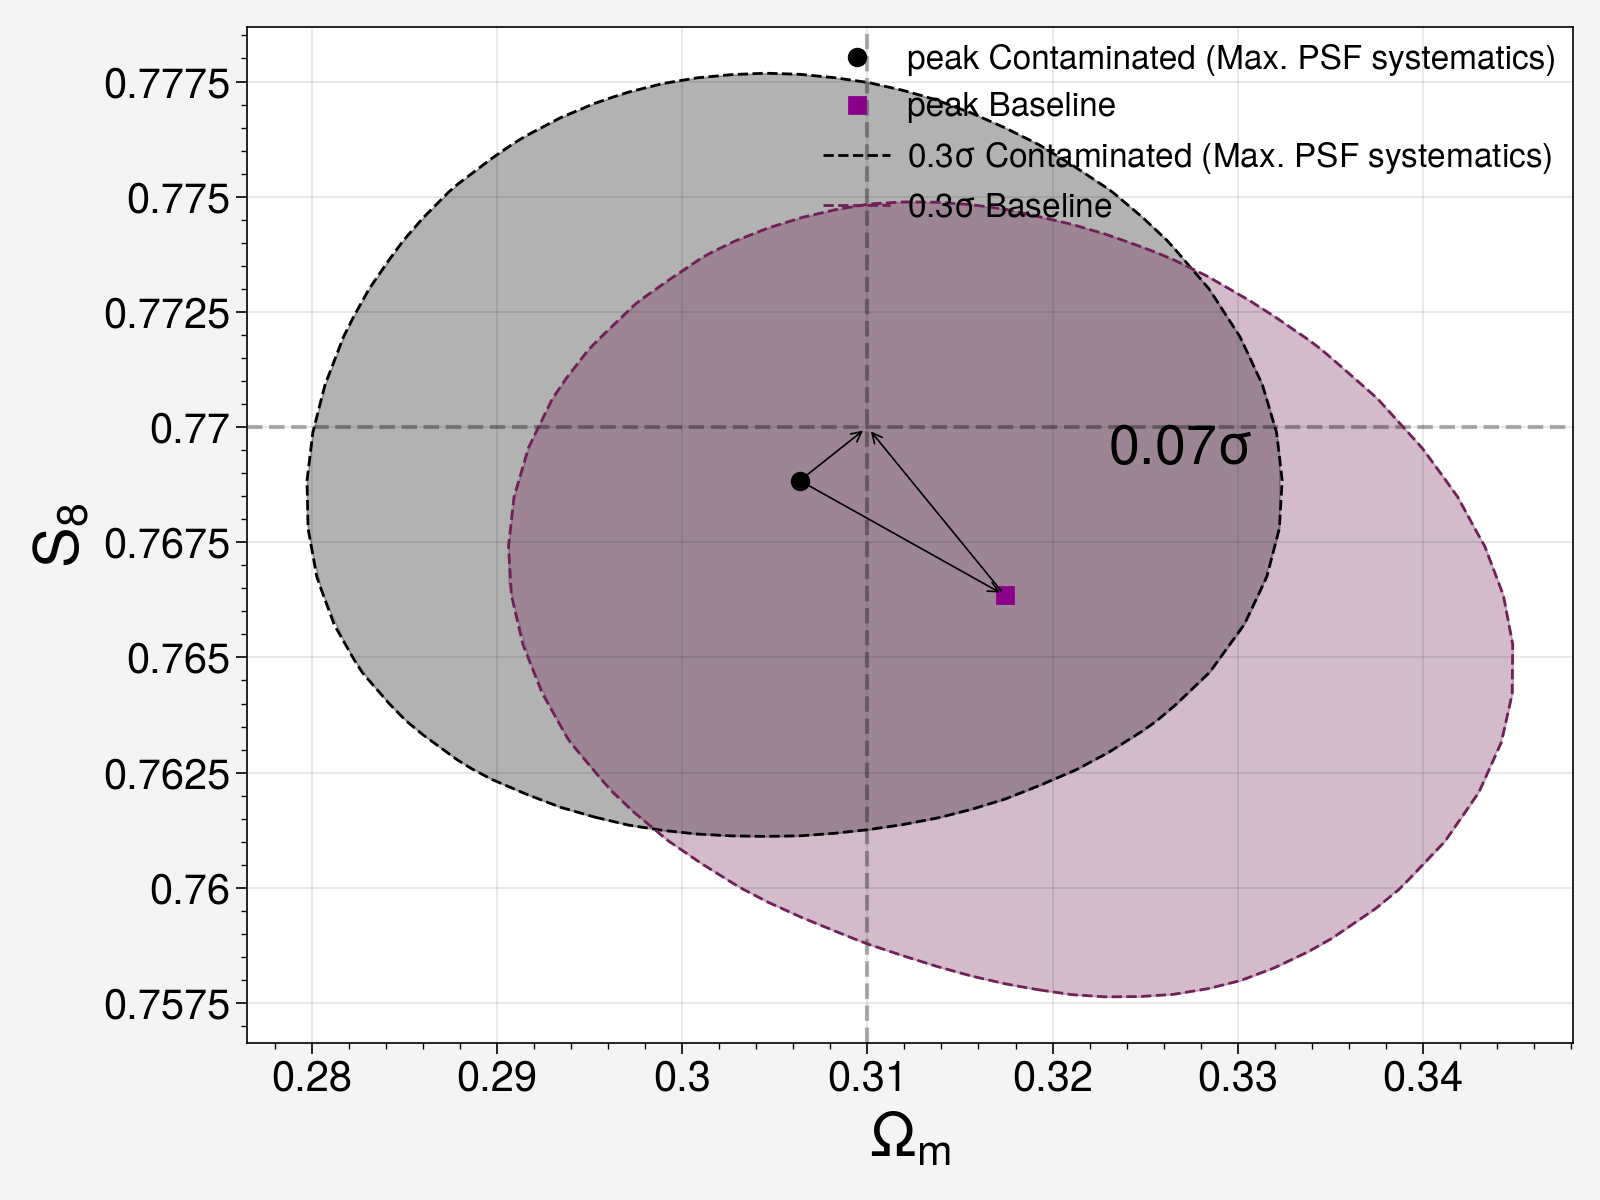

In [3]:
chain_base = chain(filename=filename_baseline_nocuts)
chain_maxcont = chain(filename=filename_maxPSFnocuts)

chain_base.add_s8()
chain_maxcont.add_s8()

chains_contaminations = [chain_maxcont]
chains_labels = ['Contaminated (Max. PSF systematics)']
figure_labels = ['maxPSFsys']
for i,c_ in enumerate(chains_contaminations):
    calculate_bias_1d(chain1=chain_base,
                      chain2=c_,
                      show=True,
                      weights_list=None,
                      input_value=[0.77], 
                      xlims=(0.7,0.825),
                      colours=['k','darkmagenta'],
                      labels=[chains_labels[i], 'Baseline'])

    # Text label with DChisq threshold
    # plt.text(x=0.85,y=1.1,s=f'$\Delta \chi^2 = 0.5$',fontsize=15)
    plt.legend(loc='upper right',frameon=False,fontsize=12)
    plt.tight_layout()
    # plt.savefig(os.path.join(path_save,'bias1D_nlabaseline_cont-%s_NOCUTS.pdf'%figure_labels[i]), bbox_inches='tight')
    plt.show()
    
for i,c_ in enumerate(chains_contaminations):
    calculate_bias_2d(chain1=chain_base,
                      chain2=c_,
                      show=True,
                      weights_list=None,
                      input_values=[0.77,0.31],
                      xy=(0.34,0.61),
                      labels=[chains_labels[i], 'Baseline'])


    plt.legend(loc='upper right',frameon=False,fontsize=12)
    plt.tight_layout()
    # plt.savefig(os.path.join(path_save,'bias2D_nlabaseline_cont-%s_NOCUTS.pdf'%figure_labels[i]), bbox_inches='tight')
    plt.show()

## pu-stellar

In [7]:
path_chains = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/chains/'
path_save = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER'

filename_y6dz_stellar = os.path.join(path_chains,'pu_stellar/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_y6dz = os.path.join(path_chains,'pz/y6dz/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')
filename_alex = os.path.join(path_chains,'alex/chain_d1_l-hm20f-nla-bfix_testrun.nautilus.FIDUCIAL_DVv5.0.fits.scales_1x2pt_chi2_3.50_v5.ini.txt')

\begin{table}
    \centering
    \caption{}
    \label{tab:model_params}
    \begin{tabular}{cccc}
        \hline
		Model & $\Omega_{{m}}$ & $\sigma_{8}$ & $S_{{8}}$ \\ 
		\hline
		Y6 dz & $0.317^{+0.052}_{-0.048}$ & $0.734^{+0.069}_{-0.063}$ & $0.764\pm 0.019$ \\ 
		Y6 dz (Alex) & $0.321^{+0.051}_{-0.049}$ & $0.732^{+0.068}_{-0.063}$ & $0.764^{+0.018}_{-0.019}$ \\ 
		\hline
    \end{tabular}
\end{table}


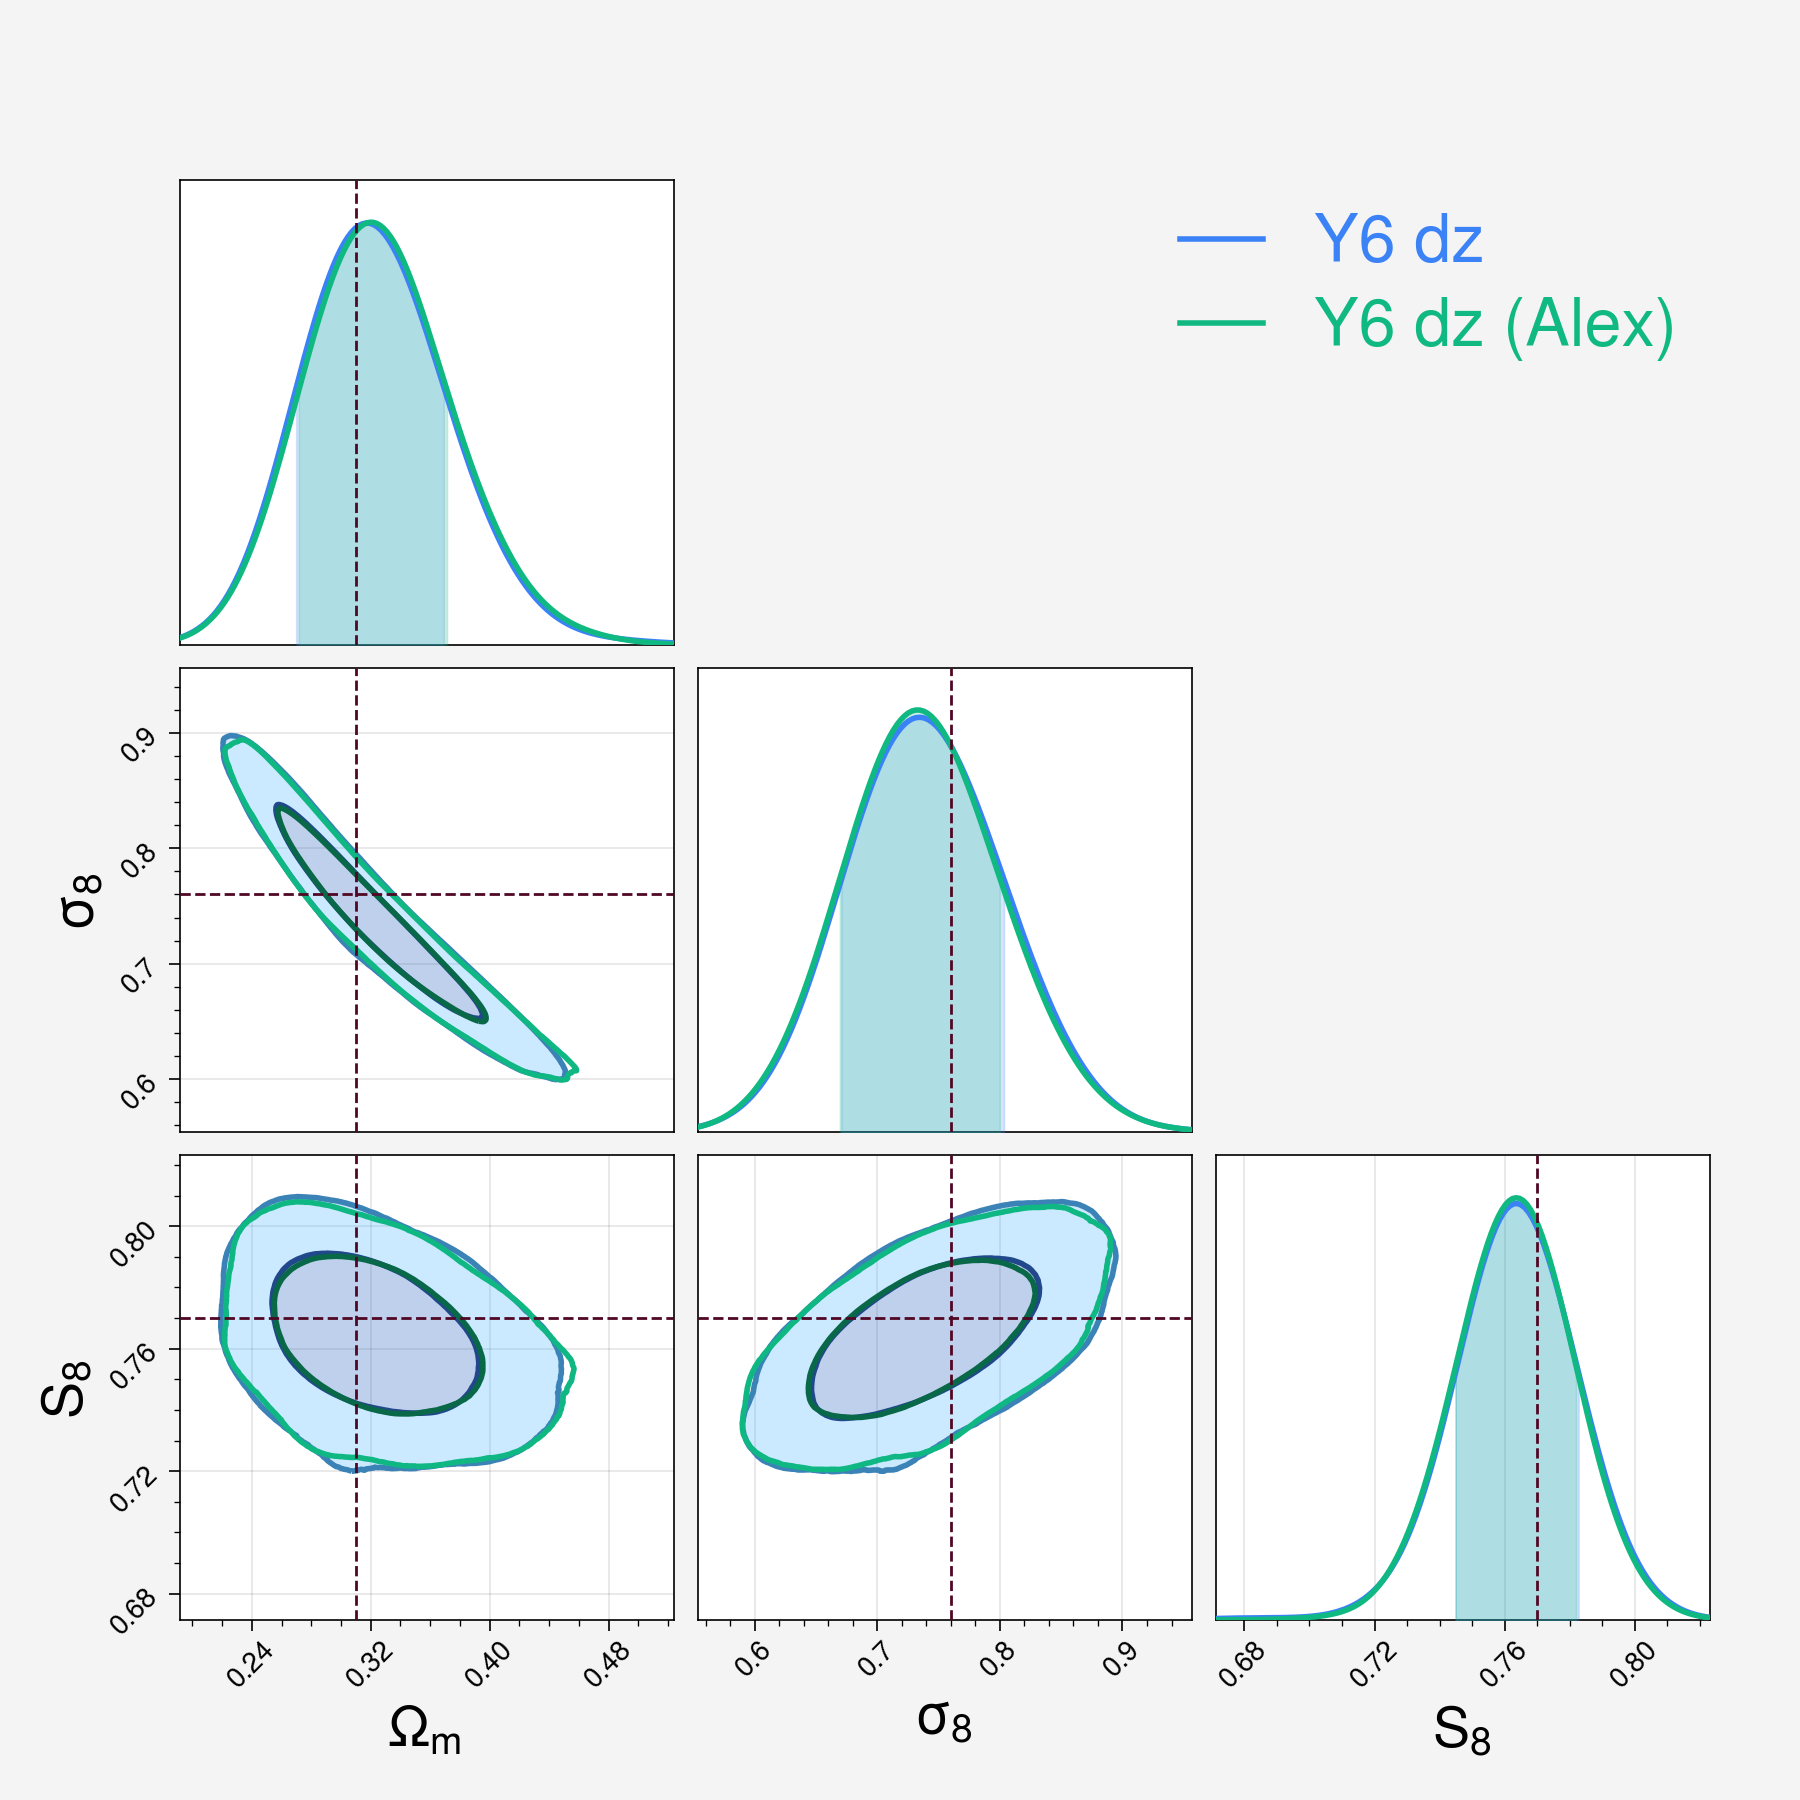

In [8]:
c = ChainConsumer()
labels = np.array(['Y6 dz', 'Y6 dz (Alex)'])
lstyles = ['-', '-']
Color = ['#e13102','#016e51'] 
alphas = [0.3,0.,] 
chains = [np.genfromtxt(filename_y6dz, names = True, deletechars='', case_sensitive='lower'), 
          np.genfromtxt(filename_alex, names = True, deletechars='', case_sensitive='lower'), ] 
plot_chains(c, chains, labels, lstyles, alphas, Color, recenter=False)